# Simulations M1 Internship - uncertainty propagation in epidemiological models

Chloé His - Second year of magistère of mathematics - ENS Rennes & University of Rennes

### The libraries to import

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import ot 
from scipy.integrate import solve_ivp
import seaborn as sns
from sklearn.mixture import GaussianMixture
import torch
import warnings
os.environ["OMP_NUM_THREADS"] = "2"

rng = np.random.default_rng()

### To prevent errors

In [2]:
def is_positive_definite(matrix):
    try:
        np.linalg.cholesky(matrix)
        return True
    except np.linalg.LinAlgError:
        return False

### For techinical reasons

In [3]:
COLOR=['blue','orange','green','red','purple','brown','gray','pink','olive','cyan']

### Calculation of the Wasserstein distance

In [4]:
def W2_distance(X, Y): # Calculation of W2 distance for samples of points
    valid_X = np.isfinite(X).all(axis=1)
    valid_Y = np.isfinite(Y).all(axis=1)
    X = X[valid_X]
    Y = Y[valid_Y]
    N = min(len(X), len(Y))
    X = X[np.random.choice(len(X), N, replace=False)]
    Y = Y[np.random.choice(len(Y), N, replace=False)]
    M = ot.dist(X, Y, metric='euclidean')**2
    a = np.ones(N) / N
    b = np.ones(N) / N
    return np.sqrt(ot.emd2(a, b, M))

def W2_distance_tensor(X, Y): # Calculation of W2 distance for samples of points
    valid_X = np.isfinite(X).all(axis=1)
    valid_Y = np.isfinite(Y).all(axis=1)
    X = X[valid_X]
    Y = Y[valid_Y]
    N = min(len(X), len(Y))
    X = X[np.random.choice(len(X), N, replace=False)]
    Y = Y[np.random.choice(len(Y), N, replace=False)]
    M = torch.tensor(ot.dist(X, Y) , requires_grad=True)
    a = torch.ones(N , requires_grad=True) / N
    b = torch.ones(N , requires_grad=True) / N
    return torch.sqrt(ot.emd2(a, b, M))

## Class Integrator to do the main structure of the solving

In [5]:
class Integrator:
    def __init__(self, t_span, x0, h, R, f):
        """
        Parameters:
            f : ODE function
            t_span : start and end times 
            x0 : initial condition 
            h : step size
            R : model parameter
        """
        self.f = f
        self.t_span = t_span
        self.x0 = x0
        self.h = h
        self.R = R

    def step(self, x, t):
        pass

    def solve(self):
        """
        Solve the ODE system using the specified step method.
        """
        t_values = [self.t_span[0]]
        x_values = [self.x0]
        t = self.t_span[0]
        x = self.x0

        while t < self.t_span[1]:
            x = self.step(x, t) 
            t += self.h
            t_values.append(t)
            x_values.append(x)

        return np.array(t_values), np.array(x_values)

### Definition of the subclass EE for the Euler method

In [6]:
class EE(Integrator):
    def __init__(self, t_span, x0, h, R, f):
        super().__init__(t_span, x0, h, R, f)

    def step(self, x, t):
        """
        Compute the next step using the Explicit Euler method.
        """
        return x + self.h * self.f(t, x, self.R)

### Definition of the subclass RK4 for the Runge-Kutta 4 method

In [7]:
class RK4(Integrator):
    def __init__(self, t_span, x0, h, R, f):
        super().__init__(t_span, x0, h, R, f)

    def step(self, x, t):
        """
        Compute the next step using the Runge-Kutta 4 method.
        """
        k1 = self.f(t, x, self.R)
        k2 = self.f(t + self.h / 2, x + self.h / 2 * k1, self.R)
        k3 = self.f(t + self.h / 2, x + self.h / 2 * k2, self.R)
        k4 = self.f(t + self.h, x + self.h * k3, self.R)
        return x + self.h / 6 * (k1 + 2 * k2 + 2 * k3 + k4)

## Definition of the class Evolution to give the different ODEs we study and plots methods

In [8]:
class Evolution:
    def __init__(self, t_span, x0, h, R, f):
        """
        Parameters:
            f : ODE function
            t_span : start and end times 
            x0 : initial condition 
            h : step size
            R : model parameter
        """
        self.f = f
        self.t_span = t_span
        self.x0 = x0
        self.h = h
        self.R = R
        
    def time_trajectory(self):
        plt.figure(figsize=(10, 6))
        
        # Solve using Explicit Euler
        solver_ee = EE(self.t_span, self.x0, self.h, self.R,self.f)
        t_values_ee, x_values_ee = solver_ee.solve()
        
        # Solve using Runge-Kutta 4
        solver_rk4 = RK4(self.t_span, self.x0, self.h, self.R, self.f)
        t_values_rk4, x_values_rk4 = solver_rk4.solve()

        for i in range (len(x0)):
            plt.plot(t_values_rk4, x_values_rk4[:, i], label=f"{self.Noms_var[i]} RK4")
            plt.plot(t_values_ee, x_values_ee[:, i], linestyle="--", label=f"{self.Noms_var[i]} EE")
            

        plt.xlabel("Time", fontsize=16)
        plt.ylabel("Number of individuals", fontsize=16)
        plt.xticks(fontsize=18)
        plt.yticks(fontsize=18)
        plt.title(f"Trajectories of the {self.Noms_var[-1]} ODE System given initial conditions {self.x0} \n with parameters {self.R} and a subdivision step h={self.h}", fontsize=18)
        plt.legend(fontsize=16)
        plt.grid()
        downloads_path = os.path.join(os.path.expanduser("~"), "Downloads")
        filename = os.path.join(downloads_path, f"Time_trajectories_{self.Noms_var[-1]}_Model.png")

        plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.show()
        
    def empirical_mean(self,n_particles,cov):
        
        if not is_positive_definite(cov):
            raise ValueError("Covariance matrix is not positive definite. Please check the values.")
            
        particles = np.random.multivariate_normal(self.x0, cov, size=n_particles) # Each particle small perturbation around x0

        IntegratorClass = RK4  
        all_trajectories = []

        for i in range(n_particles):
            X = particles[i]
            integrator = IntegratorClass(self.t_span, X, self.h, self.R, self.f)
            t_values, x_values = integrator.solve()
            all_trajectories.append(x_values)

        all_trajectories = np.array(all_trajectories)
        mean_trajectory = np.mean(all_trajectories, axis=0)
        return(mean_trajectory) 
    
    def empirical_var(self,n_particles,cov):
        
        if not is_positive_definite(cov):
            raise ValueError("Covariance matrix is not positive definite. Please check the values.")
            
        particles = np.random.multivariate_normal(self.x0, cov, size=n_particles) # Each particle small perturbation around x0

        IntegratorClass = RK4  
        all_trajectories = []

        for i in range(n_particles):
            X = particles[i]
            integrator = IntegratorClass(self.t_span, X, self.h, self.R, self.f)
            t_values, x_values = integrator.solve()
            all_trajectories.append(x_values)

        all_trajectories = np.array(all_trajectories)
        
        covariances = []
        for t_index in range(len(t_values)):
            cov_t = np.cov(all_trajectories[:, t_index, :].T)
            covariances.append(cov_t)
        variances=[]
        for i in range (len(self.x0)):
            variances.append(np.array([covt[i, i] for covt in covariances]))
        variances=np.array(variances)
        return(variances)
    
    def plot_empirical_var(self,n_particles,cov):
        
        if not is_positive_definite(cov):
            raise ValueError("Covariance matrix is not positive definite. Please check the values.")
            
        particles = np.random.multivariate_normal(self.x0, cov, size=n_particles) # Each particle small perturbation around x0

        IntegratorClass = RK4  
        all_trajectories = []

        for i in range(n_particles):
            X = particles[i]
            integrator = IntegratorClass(self.t_span, X, self.h, self.R, self.f)
            t_values, x_values = integrator.solve()
            all_trajectories.append(x_values)

        all_trajectories = np.array(all_trajectories)
        
        covariances = []
        for t_index in range(len(t_values)):
            cov_t = np.cov(all_trajectories[:, t_index, :].T)
            covariances.append(cov_t)
        plt.figure(figsize=(12, 6))
        for i in range (len(self.x0)):
            variances = [cov[i, i] for cov in covariances] 
            plt.plot(t_values, variances, color=COLOR[i], label=f'Empirical variance of {self.Noms_var[i]}')

        plt.title(f'Empirical variances in the {self.Noms_var[-1]} Model with gaussian initial conditions over Time', fontsize=18)
        plt.xlabel('Time',fontsize=16)
        plt.ylabel('Variance',fontsize=16)
        plt.xticks(fontsize=18)
        plt.yticks(fontsize=18)
        plt.legend(fontsize=16)
        plt.grid(True)
        downloads_path = os.path.join(os.path.expanduser("~"), "Downloads")
        filename = os.path.join(downloads_path, "Empirical_Variance_Gaussian_example.png")

        plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.tight_layout()
        plt.show()
        
    def plot_empirical_var_GMM(self,n_particles,X0,COV,omega):

        for i in range(len(COV)):
            if not is_positive_definite(COV[i]):
                raise ValueError(f"Covariance matrix {COV[i]} at the {i}-th covariance is not positive definite. Please check the values.")

        particles = []
        group_each_GMM = [[] for i in range(len(X0))] # Remember the initial GMM 
        for i in range(n_particles):
            index=rng.choice(len(omega),p=omega) # Choose the right index according to the initial weight as probability
            group_each_GMM[index].append(i)
            particles.append(np.random.multivariate_normal(X0[index], COV[index]))
        particles=np.array(particles)

        IntegratorClass = RK4  
        all_trajectories = []

        for i in range(n_particles):
            X = particles[i]
            integrator = IntegratorClass(self.t_span, X, self.h, self.R, self.f)
            t_values, x_values = integrator.solve()
            all_trajectories.append(x_values)

        all_trajectories = np.array(all_trajectories)
        
        plt.figure(figsize=(12, 6))
        for j in range(len(X0)):
            covariances = []
            GMM_j=np.array([all_trajectories[k] for k in group_each_GMM[j]])
            for t_index in range(len(t_values)):
                cov_t = np.cov(GMM_j[:, t_index, :].T)
                covariances.append(cov_t)
            for i in range (len(self.x0)):
                variances = [cov[i, i] for cov in covariances] 
                plt.plot(t_values, variances, color=COLOR[i], label=f'Empirical variances of {self.Noms_var[i]}' if j ==0 else "")

        plt.title(f'Empirical variances in the {self.Noms_var[-1]} Model with GMM initial conditions over Time', fontsize=18)
        plt.xlabel('Time',fontsize=16)
        plt.ylabel('Variance',fontsize=16)
        plt.xticks(fontsize=18)
        plt.yticks(fontsize=18)
        plt.legend(fontsize=16)
        plt.grid(True)
        downloads_path = os.path.join(os.path.expanduser("~"), "Downloads")
        filename = os.path.join(downloads_path, "Empirical_Variance_GMM_example.png")

        plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.tight_layout()
        plt.show()
        
    def uncertain_trajectory(self,n_particles,cov):

        if not is_positive_definite(cov):
            raise ValueError("Covariance matrix is not positive definite. Please check the values.")
            
        particles = np.random.multivariate_normal(self.x0, cov, size=n_particles) #Each particle small perturbation around mean

        IntegratorClass = RK4  
        all_trajectories = []

        for i in range(n_particles):
            X = particles[i]
            integrator = IntegratorClass(self.t_span, X, self.h, self.R, self.f)
            t_values, x_values = integrator.solve()
            all_trajectories.append(x_values)

        all_trajectories = np.array(all_trajectories)
        mean_trajectory = np.mean(all_trajectories, axis=0)

        plt.figure(figsize=(12, 6))
        for j in range(len(self.x0)):
            for i in range(n_particles):
                plt.plot(t_values, all_trajectories[i][:, j], color=COLOR[j], alpha=0.3, label=f'Particles {self.Noms_var[j]}' if i == 0 else "")
            
            plt.plot(t_values, mean_trajectory[:, j], color=COLOR[-j-1], label=f'Empirical mean {self.Noms_var[j]}')

        plt.title(f'Trajectories of the {self.Noms_var[-1]} Model and Empirical mean evolution with a gaussian noise', fontsize=18)
        plt.xlabel('Time', fontsize=16)
        plt.ylabel(r'Number of individuals', fontsize=16)
        plt.xticks(fontsize=18)
        plt.yticks(fontsize=18)
        plt.legend(fontsize=16)
        plt.grid(True)
        downloads_path = os.path.join(os.path.expanduser("~"), "Downloads")
        filename = os.path.join(downloads_path, "Uncertain_trajectories_Gaussian_example.png")

        plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.tight_layout()
        plt.show()
        
    def uncertain_trajectory_GMM(self,n_particles,X0,COV,omega):

        for i in range(len(COV)):
            if not is_positive_definite(COV[i]):
                raise ValueError(f"Covariance matrix {COV[i]} at the {i}-th covariance is not positive definite. Please check the values.")
        
        particles = []
        group_each_GMM = [[] for i in range(len(X0))] # Remember the initial GMM 
        for i in range(n_particles):
            index=rng.choice(len(omega),p=omega) # Choose the right index according to the initial weight as probability
            group_each_GMM[index].append(i)
            particles.append(np.random.multivariate_normal(X0[index], COV[index]))
        particles=np.array(particles)

        IntegratorClass = RK4  
        all_trajectories = []

        for i in range(n_particles):
            X = particles[i]
            integrator = IntegratorClass(self.t_span, X, self.h, self.R, self.f)
            t_values, x_values = integrator.solve()
            all_trajectories.append(x_values)

        all_trajectories = np.array(all_trajectories)
        mean_trajectory=[]
        for i in range(len(X0)):
            mean_trajectory.append(np.mean(np.array([all_trajectories[k] for k in group_each_GMM[i]]), axis=0)) # Empirical mean for each Gaussian

        plt.figure(figsize=(12, 6))
        for j in range(len(X0[0])):
            for i in range(n_particles):
                plt.plot(t_values, all_trajectories[i][:, j], color=COLOR[j], alpha=0.3, label=f'Particles {self.Noms_var[j]}' if i == 0 else "")
            
            for i in range(len(X0)):
                plt.plot(t_values, mean_trajectory[i][:, j], color=COLOR[-j-1], label=f'Empirical means {self.Noms_var[j]}' if i ==0 else "")

        plt.title(f'Trajectories of the {self.Noms_var[-1]} Model and Empirical mean evolution with a GMM noise', fontsize=18)
        plt.xlabel('Time', fontsize=16)Evolution
        plt.ylabel(r'Number of individuals', fontsize=16)
        plt.xticks(fontsize=18)
        plt.yticks(fontsize=18)
        plt.legend(fontsize=16)
        plt.grid(True)
        downloads_path = os.path.join(os.path.expanduser("~"), "Downloads")
        filename = os.path.join(downloads_path, "Uncertain_trajectories_GMM_example.png")

        plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.tight_layout()
        plt.show()
        
    def marginals(self,n_particles,cov,precision):
        
        if not is_positive_definite(cov):
            raise ValueError("Covariance matrix is not positive definite. Please check the values.")
            
        particles = np.random.multivariate_normal(self.x0, cov, size=n_particles) #Each particle small perturbation around mean

        IntegratorClass = RK4  
        all_trajectories = []

        for i in range(n_particles):
            X = particles[i]
            integrator = IntegratorClass(self.t_span, X, self.h, self.R, self.f)
            t_values, x_values = integrator.solve()
            all_trajectories.append(x_values)

        all_trajectories = np.array(all_trajectories)
        
        time_indices = [0, len(t_values)//4, len(t_values)//2, -1]  # Start, middle, end
        
        for j in range (len(self.x0)):
            
            plt.figure(figsize=(12, 8))

            for i, idx in enumerate(time_indices):
                plt.subplot(2, 2, i+1)
                Marginal_values = all_trajectories[:, idx, j]
                sns.kdeplot(Marginal_values, label=f'Time t = {t_values[idx]:.2f}', fill=True,bw_adjust=precision)
                plt.scatter(Marginal_values, [-0.01]*len(Marginal_values), color='black', alpha=0.5, s=10, label=f'{self.Noms_var[j]}')
                plt.title(f'Distribution of {self.Noms_var[j]} \n in the {self.Noms_var[-1]} Model at t = {t_values[idx]:.2f}', fontsize=18)
                plt.xlabel(f'{self.Noms_var[j]}', fontsize=18)
                plt.xticks(fontsize=18)
                plt.yticks(fontsize=18)
                plt.legend(loc='upper left', fontsize=12)
                plt.ylabel('Density',fontsize=18)
            plt.tight_layout()
            downloads_path = os.path.join(os.path.expanduser("~"), "Downloads")
            filename = os.path.join(downloads_path, f"Marginals_Gaussian_example_{self.Noms_var[j]}.png")

            plt.savefig(filename, dpi=300, bbox_inches='tight')

            plt.show()
            
    def marginals_GMM(self,n_particles,X0,COV,omega,precision):
        
        if not is_positive_definite(cov):
            raise ValueError("Covariance matrix is not positive definite. Please check the values.")
            
        particles = []
        for i in range(n_particles):
            index=rng.choice(len(omega),p=omega) # Choose the right index according to the initial weight as probability
            particles.append(np.random.multivariate_normal(X0[index], COV[index]))
        particles=np.array(particles)

        IntegratorClass = RK4  
        all_trajectories = []

        for i in range(n_particles):
            X = particles[i]
            integrator = IntegratorClass(self.t_span, X, self.h, self.R, self.f)
            t_values, x_values = integrator.solve()
            all_trajectories.append(x_values)

        all_trajectories = np.array(all_trajectories)
        
        time_indices = [0, len(t_values)//4, len(t_values)//2, -1]  # Start, middle, end
        
        for j in range (len(self.x0)):
            
            plt.figure(figsize=(12, 8))

            for i, idx in enumerate(time_indices):
                plt.subplot(2, 2, i+1)
                Marginal_values = all_trajectories[:, idx, j]
                sns.kdeplot(Marginal_values, label=f'Time t = {t_values[idx]:.2f}', fill=True,bw_adjust=precision)
                plt.scatter(Marginal_values, [-0.01]*len(Marginal_values), color='black', alpha=0.5, s=10, label=f'{self.Noms_var[j]}')
                plt.title(f'Distribution of {self.Noms_var[j]} \n in the {self.Noms_var[-1]} Model at t = {t_values[idx]:.2f}', fontsize=18)
                plt.xlabel(f'{self.Noms_var[j]}', fontsize=18)
                plt.xticks(fontsize=18)
                plt.yticks(fontsize=18)
                plt.legend(loc='upper left', fontsize=12)
                plt.ylabel('Density',fontsize=18)
            plt.tight_layout()
            downloads_path = os.path.join(os.path.expanduser("~"), "Downloads")
            filename = os.path.join(downloads_path, f"Marginals_GMM_example_{self.Noms_var[j]}.png")

            plt.savefig(filename, dpi=300, bbox_inches='tight')

            plt.show()
            
    def error_approx_law_GMM(self,n_particles,X0,COV,omega,n_components):
        with warnings.catch_warnings(record=True):
            ## Define the initial GMM / Initialisation
            particles = []
            gaussians=[[] for i in range(len(omega))] # List to store the particules following the same gaussian
            for i in range(n_particles):
                index=rng.choice(len(omega),p=omega) # Choose the right index according to the initial weight as probability
                P=np.random.multivariate_normal(X0[index], COV[index])
                gaussians[index].append(i) # Add the index in the amount of particules, which follow the same gaussian law 
                                           #   (useful later)
                particles.append(P) # Add P in the amount of all the particles
            particles=np.array(particles)

            ## First resolution with the empirical measure
            IntegratorClass = RK4  
            all_trajectories = []

            for i in range(n_particles):
                X = particles[i]
                integrator = IntegratorClass(self.t_span, X, self.h, self.R, self.f)
                t_values, x_values = integrator.solve()
                all_trajectories.append(x_values)

            all_trajectories = np.array(all_trajectories)

            law_emp=np.array([[all_trajectories[:,i,j] for i in range(len(t_values))] for j in range(len(self.x0))])

            ## Second resolution with the expectation maximization
            law_exp_max=[]
            for i in range (len(t_values)):
                gmm = GaussianMixture(n_components) # Create an instance GMM
                gmm.fit(all_trajectories[:,i,:]) # Find the GMM corresponding to the trajectories at time i
                law_exp_max.append(gmm.sample(n_particles)[0]) # Store a sample of particles following the GMM found
            law_exp_max=np.array([[law_exp_max[i][:,j] for i in range (len(t_values))] for j in range (len(self.x0))])

            ## Third resolution with the minimization of the Wasserstein distance using Pytorch (Pytorch method)
            
            law_min_Wass=[]
            
            # 1. Keep tracking the particules linked to different gaussians over time (for example in adding this in a list in 
            #    index? Or by creating a list containing a list of the particules in each gaussian?) => see initialisation!
            
            # 2. Define a torch of different possible weight that can be carried by the GMM over time
            
            w = torch.tensor(omega, requires_grad=True) # weights for the source distributions
            
            # 3. At each step of time, calculate the empirical mean and covariance to know the evolution of each gaussian
            
            for i in range(len(t_values)): 
                Mean_min_Wass=[[] for k in range(len(omega))] # A list to store the empirical mean of each gaussian over time
                Covar_min_Wass=[[] for k in range(len(omega))] # The same for the empirical covariance of each gaussian
                for k in range(len(omega)): # For each gaussian
                    Sample=np.array([all_trajectories[j,i,:] for j in gaussians[k]])
                    Mean_min_Wass[k]=np.mean(Sample, axis=0) # Empirical mean
                    Covar_min_Wass[k]=np.cov(Sample.T) # Empirical covariance
            
            # 4. Find the corresponding weight in the list thanks to a gradient descent method / Pytorch

                lr = 1e-2  # learning rate
                losses = []  # loss along the iterations
                
                n_iter=int(n_particles*0.1)
                def get_loss(w):
                    particles_min_Wass=torch.zeros((n_iter,len(self.x0)), dtype=torch.float64)
                    for n in range(n_iter):
                        index=torch.multinomial(w,1)
                        P=torch.distributions.multivariate_normal.MultivariateNormal(torch.tensor(Mean_min_Wass[index]),torch.tensor(Covar_min_Wass[index])).sample()
                        particles_min_Wass[n]=P # Add P in the amount of all the particles at the time i

                    # Calculation of the Wasserstein distances
                    return(W2_distance_tensor(torch.tensor(np.transpose(law_emp[:,i,:n_iter])),particles_min_Wass))

                optimizer=torch.optim.SGD([w],lr=lr,momentum=0.9)

                for j in range(n_iter):
                    optimizer.zero_grad()
                    loss = get_loss(w)
                    losses.append(float(loss))

                    loss.backward()
                    
                    optimizer.step()

                weight=w.clone().detach().numpy() # Transform the tensor to a np.array

            #    ! Pay attention if the sum of the weights is equal to 1 => It should stay a probability measure !
            
                if sum(weight)!=1: # Verification that the weights form a convex combination
                    S=sum(weight) # Total weight
                    for j in range (len(omega)):
                        weight[j]=weight[j]/S # Renormalisation
            
            # 5. When we have the global law of the GMM, pick n_particles following this law
            
                particles_min_Wass=[]
                for n in range(n_particles):
                    index=rng.choice(len(omega),p=weight)
                    P=np.random.multivariate_normal(Mean_min_Wass[index],Covar_min_Wass[index])
                    particles_min_Wass.append(P) # Add P in the amount of all the particles at the time i
                law_min_Wass.append(np.array(particles_min_Wass))
            
            # 6. If needed, reorganize the list to have the right order of index for the calculation of the W2 and the plots!
            
            law_min_Wass=np.array(law_min_Wass)
            law_min_Wass=np.array([[law_min_Wass[j,:,i] for j in range(len(t_values))] for i in range(len(self.x0))])

            ## Calculation of the Wasserstein distances

            W2_empVSexp_max=np.array([W2_distance(np.transpose(law_emp[:,j,:]),np.transpose(law_exp_max[:,j,:])) for j in range (len(t_values))])
            W2_empVSmin_Wass=np.array([W2_distance(np.transpose(law_emp[:,j,:]),np.transpose(law_min_Wass[:,j,:])) for j in range (len(t_values))])

            ## Plots of the Wasserstein distance
            plt.figure(figsize=(12, 6))

            plt.plot(t_values, W2_empVSexp_max, label=fr'$W_2(\mu(emp), \mu(exp max))$')
            plt.plot(t_values, W2_empVSmin_Wass, linestyle="dotted", label=fr'$W_2(\mu(emp), \mu(Pytor))$')

            plt.xlabel("Time", fontsize=16)
            plt.ylabel("Wasserstein distance", fontsize=16)
            plt.xticks(fontsize=16)
            plt.yticks(fontsize=16)
            plt.title(f"Wasserstein distance between empirical measure (emp) \n and the one of the GMM given by expectation maximization (exp max) \n or with the automatic Pytorch minimization (Pytor) \n in the {self.Noms_var[-1]} model", fontsize=18)
            plt.legend(fontsize=16)
            plt.grid(True)

            downloads_path = os.path.join(os.path.expanduser("~"), "Downloads")
            filename = os.path.join(downloads_path, f"Wasserstein_distance_{self.Noms_var[-1]}.png")

            plt.savefig(filename, dpi=300, bbox_inches='tight')

            plt.show()
            
            ## Plot of the trajectories among the time
            # Expectation maximization
            plt.figure(figsize=(12, 6))

            for i in range(len(self.x0)):
                for j in range(n_particles):
                    plt.plot(t_values, law_exp_max[i,:,j], color=COLOR[i], label=fr'{self.Noms_var[i]}'  if j == 0 else "")

                plt.xlabel("Time", fontsize=16)
                plt.ylabel("Parameters of the equation", fontsize=16)
                plt.xticks(fontsize=16)
                plt.yticks(fontsize=16)
                plt.title(f"Uncertain trajectories over time for a GMM given with the expectation maximization (exp max) \n method with {n_particles} particles in the {self.Noms_var[-1]} model", fontsize=18)
                plt.legend(fontsize=16)
                plt.grid(True)

            plt.show()
            # Minimization of the Wasserstein distance
            plt.figure(figsize=(12, 6))

            for i in range(len(self.x0)):
                for j in range(n_particles):
                    plt.plot(t_values, law_min_Wass[i,:,j], color=COLOR[i], label=fr'{self.Noms_var[i]}'  if j == 0 else "")

                plt.xlabel("Time", fontsize=16)
                plt.ylabel("Parameters of the equation", fontsize=16)
                plt.xticks(fontsize=16)
                plt.yticks(fontsize=16)
                plt.title(f"Uncertain trajectories over time for a GMM given by the automatic Pytorch minimization (Pytor) \n method in the {self.Noms_var[-1]} model", fontsize=18)
                plt.legend(fontsize=16)
                plt.grid(True)

            plt.show()       

### Definition of the subclass LV for the Lotka-Volterra ODE

In [9]:
class LV (Evolution):
    def ODE(t, x, R):
        """
        Defines the ODE system with uncertain parameter R.
        Parameters:
            t : float
                Current time.
            x : ndarray
                Current state vector [x1, x2].
            R : float
                Model parameter (uncertain).
        Returns:
            ndarray
                Derivatives [dx1/dt, dx2/dt].
        """
        x1, x2 = x
        dx1 = x1 * (R - x1 - 2 * x2)  
        dx2 = x2 * (2 - x1 - x2)
        return np.array([dx1, dx2])
    
    def __init__(self, t_span, x0, h, R,f=ODE):
        super().__init__(t_span, x0, h, R,f)
        self.Noms_var=['Prey','Predator','Lotka-Voltera']

    def time_trajectory(self):
        super().time_trajectory()
    
    def uncertain_trajectory(self,n_particles,cov):
        super().uncertain_trajectory(n_particles,cov)
        
    def empirical_mean(self,n_particles,cov):
        return(super().empirical_mean(n_particles,cov))
        
    def empirical_var(self,n_particles,cov):
        return(super().empirical_var(n_particles,cov))
    
    def plot_empirical_var(self,n_particles,cov):
        super().plot_empirical_var(n_particles,cov)
        
    def marginals(self,n_particles,cov,precision):
        super().marginals(n_particles,cov,precision)
        
    def uncertain_trajectory_GMM(self,n_particles,X0,COV,omega):
        super().uncertain_trajectory_GMM(n_particles,X0,COV,omega)
        
    def error_approx_law_GMM(self,n_particles,X0,COV,omega,n_components):
        super().error_approx_law_GMM(n_particles,X0,COV,omega,n_components)
        
    def plot_empirical_var_GMM(self,n_particles,X0,COV,omega):
        super().plot_empirical_var_GMM(n_particles,X0,COV,omega)
        
    def marginals_GMM(self,n_particles,X0,COV,omega,precision):
        super().marginals_GMM(n_particles,X0,COV,omega,precision)

### Definition of the subclass SIR for the SIR ODE

In [10]:
class SIR (Evolution):
    def ODE(t,x,R):
        """
        Defines the SIR ODE system with uncertain parameters beta and mu.
        Parameters:
            t : float
                Current time.
            x : ndarray
                Current state vector [s,i,r].
            R : ndarray
                Model parameters [beta,mu] (uncertain) corresponding to reproduction parameter and recovery parameter
        Returns:
            ndarray
                Derivatives [ds/dt, di/dt, dr/dt].
        """
        beta=R[0]
        mu=R[1]
        s, i, r = x
        ds = -beta*i*s
        di = beta*s*i-mu*i
        dr = mu*i
        return np.array([ds, di, dr])
    
    def __init__(self, t_span, x0, h, R, f=ODE):
        super().__init__(t_span, x0, h, R, f)
        self.Noms_var=['S','I','R','SIR']
    
    def time_trajectory(self):
        super().time_trajectory()
        
    def uncertain_trajectory(self,n_particles,cov):
        super().uncertain_trajectory(n_particles,cov)
        
    def empirical_mean(self,n_particles,cov):
        return(super().empirical_mean(n_particles,cov))
        
    def empirical_var(self,n_particles,cov):
        return(super().empirical_var(n_particles,cov))
        
    def plot_empirical_var(self,n_particles,cov):
        super().plot_empirical_var(n_particles,cov)
        
    def marginals(self,n_particles,cov,precision):
        super().marginals(n_particles,cov,precision)
        
    def uncertain_trajectory_GMM(self,n_particles,X0,COV,omega):
        super().uncertain_trajectory_GMM(n_particles,X0,COV,omega)
        
    def error_approx_law_GMM(self,n_particles,X0,COV,omega,n_components):
        super().error_approx_law_GMM(n_particles,X0,COV,omega,n_components)
        
    def plot_empirical_var_GMM(self,n_particles,X0,COV,omega):
        super().plot_empirical_var_GMM(n_particles,X0,COV,omega)
        
    def marginals_GMM(self,n_particles,X0,COV,omega,precision):
        super().marginals_GMM(n_particles,X0,COV,omega,precision)

## Tests !

### Lotka-Voltera Model

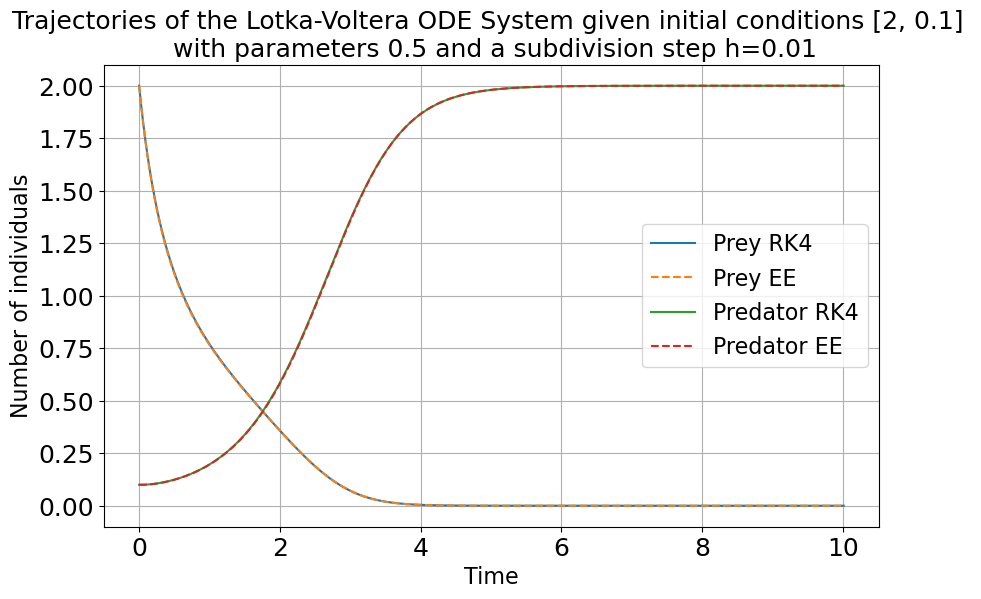

C:\Users\Chloé HIS\AppData\Local\Temp\ipykernel_22564\1396678821.py:221: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(filename, dpi=300, bbox_inches='tight')


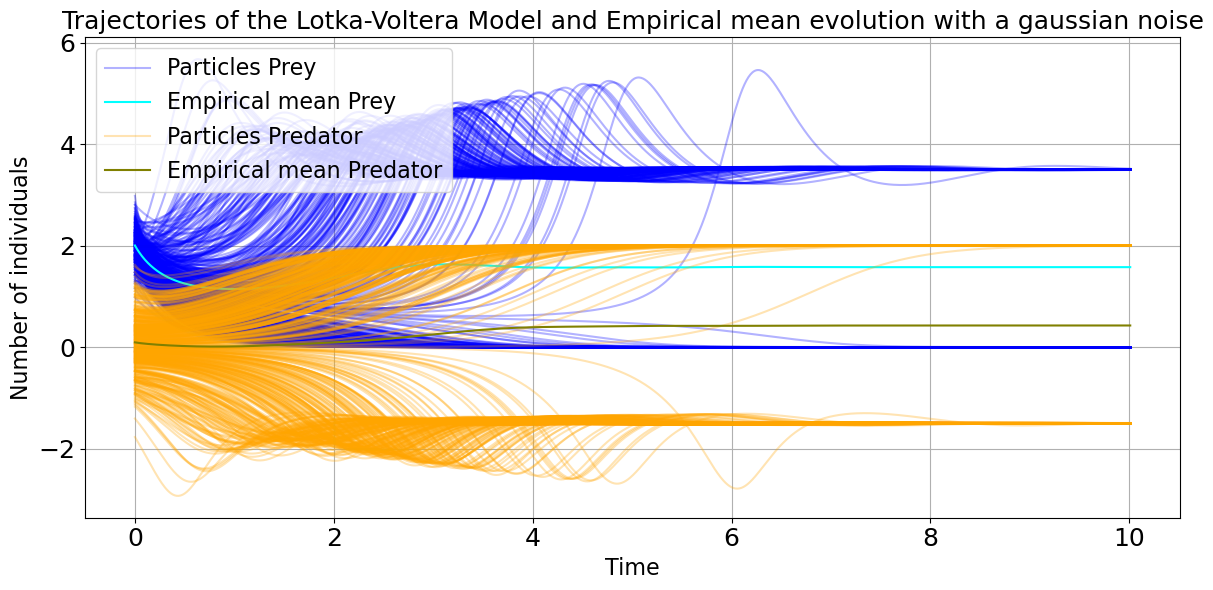

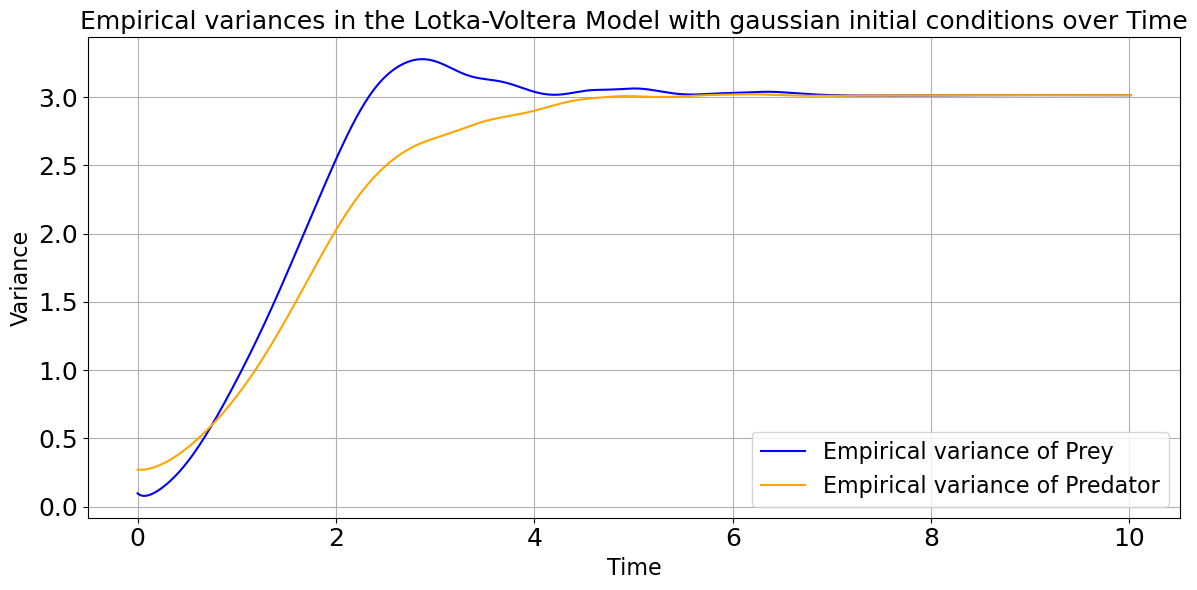

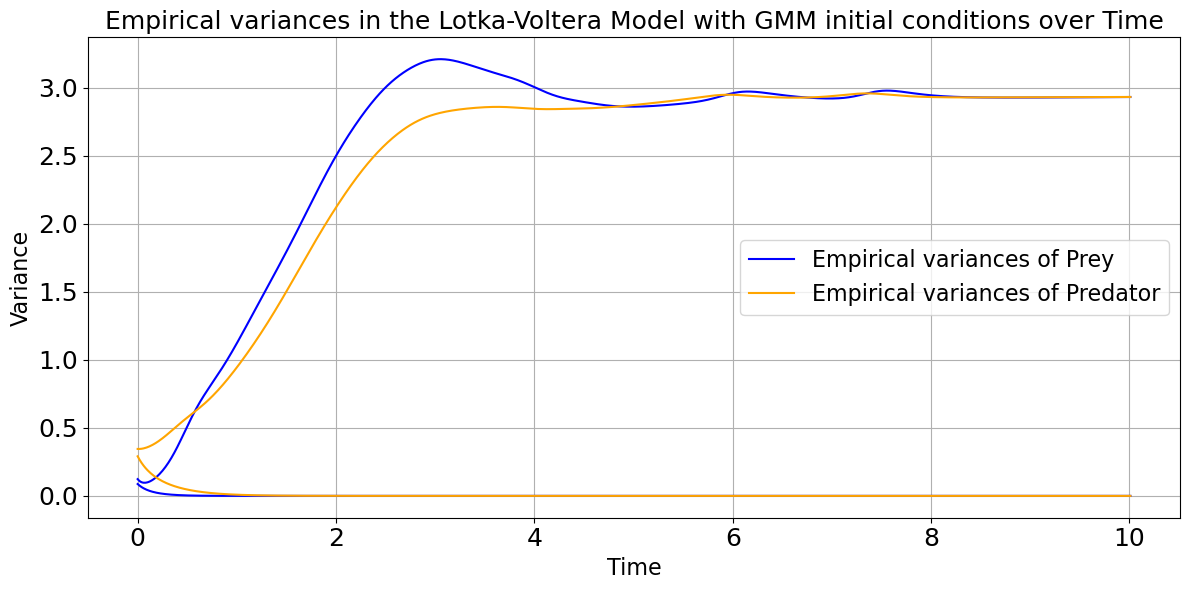

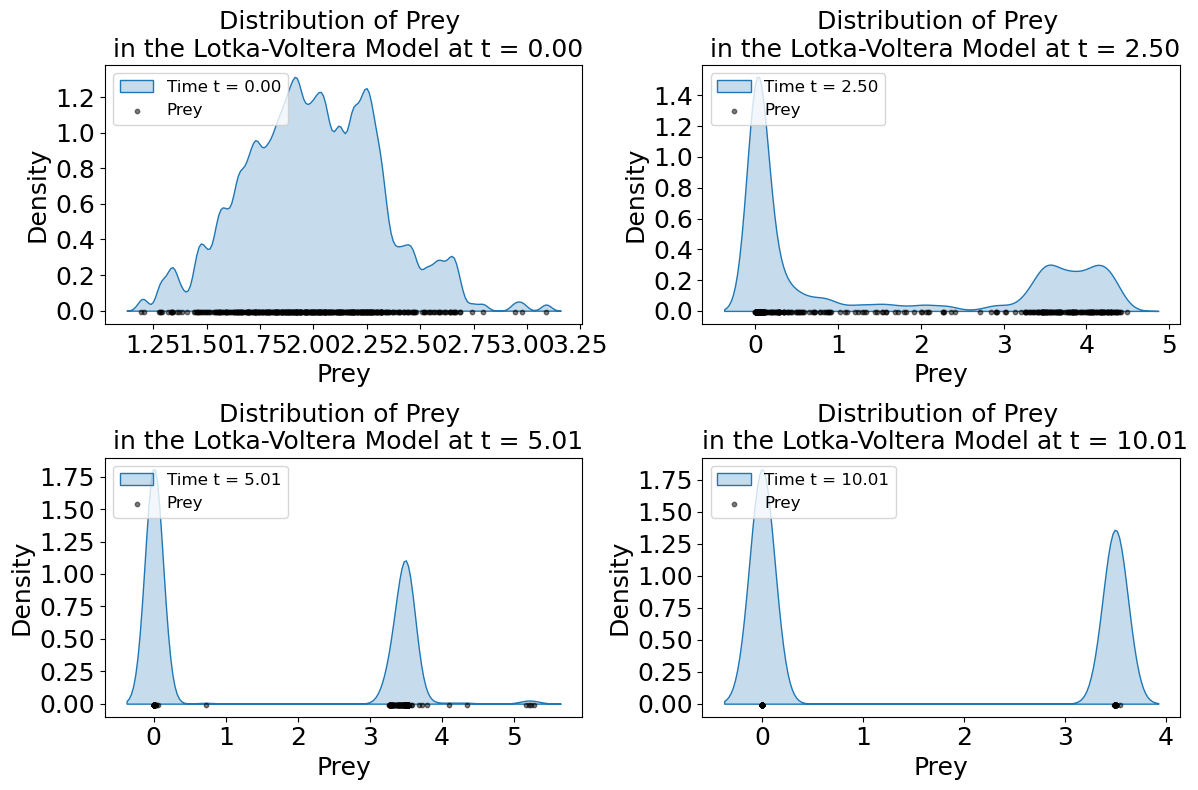

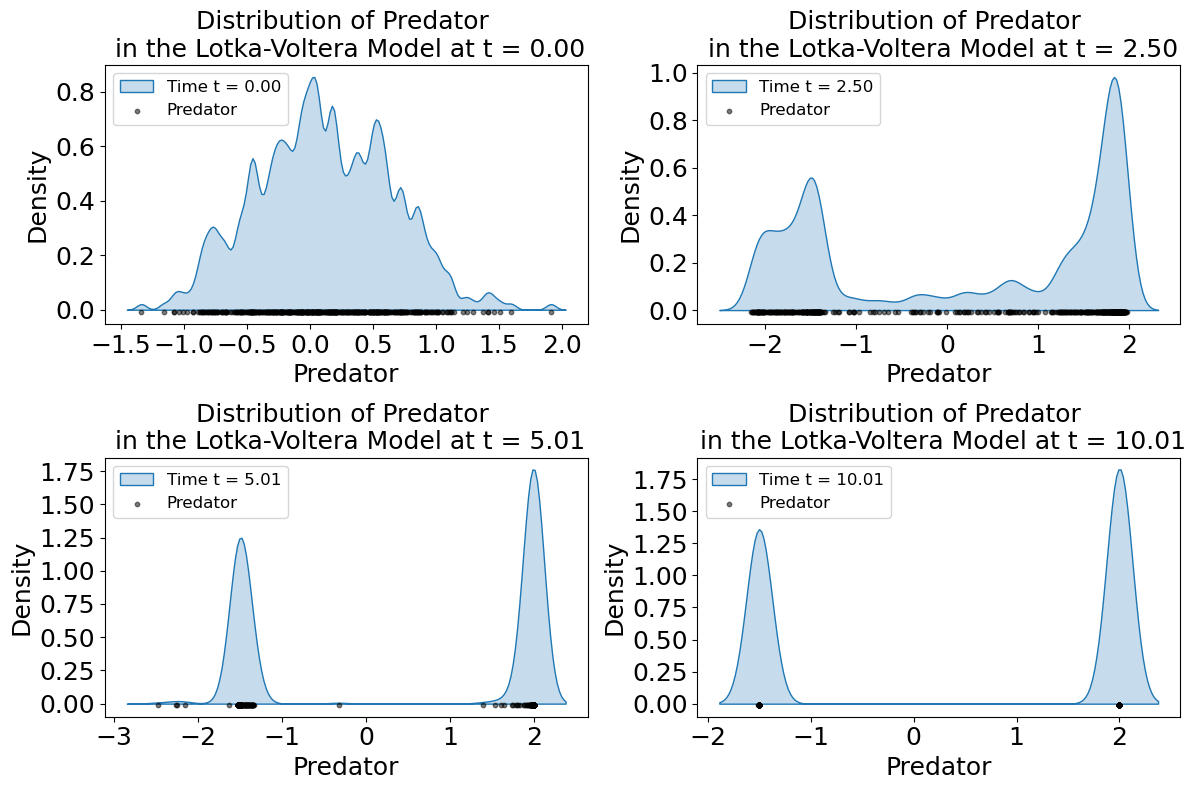

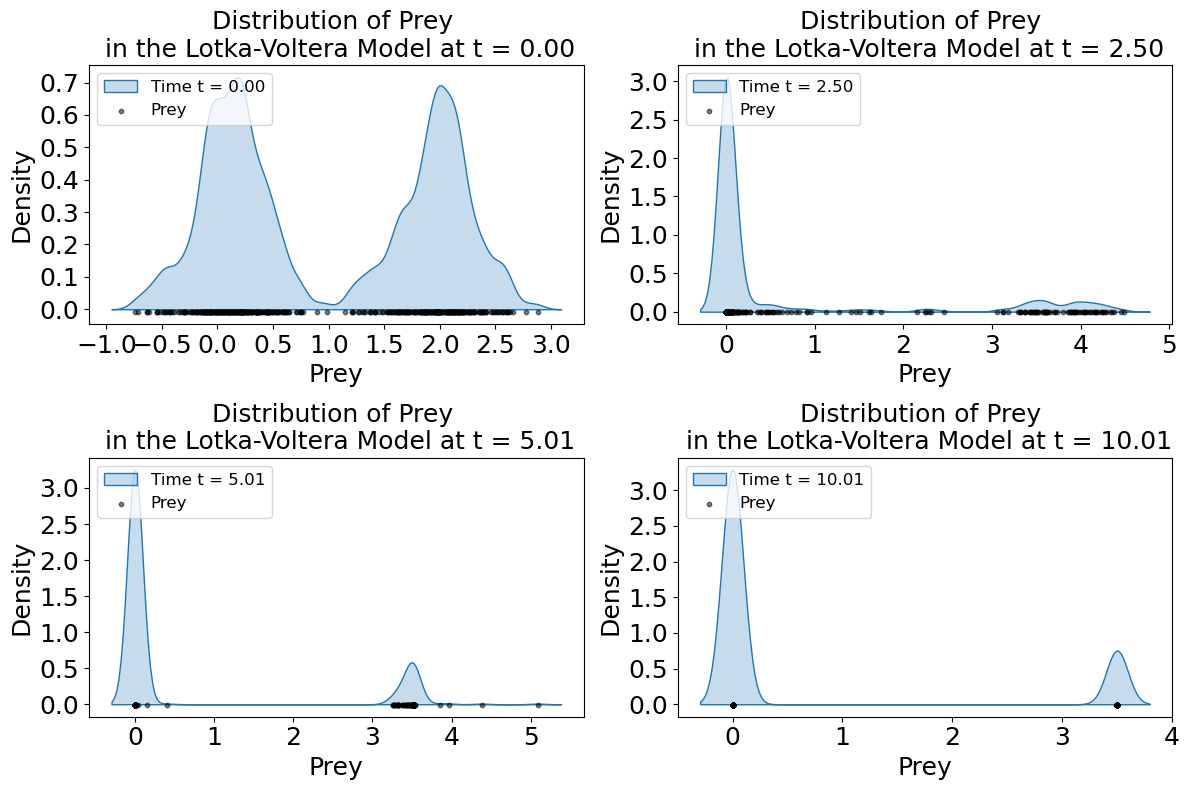

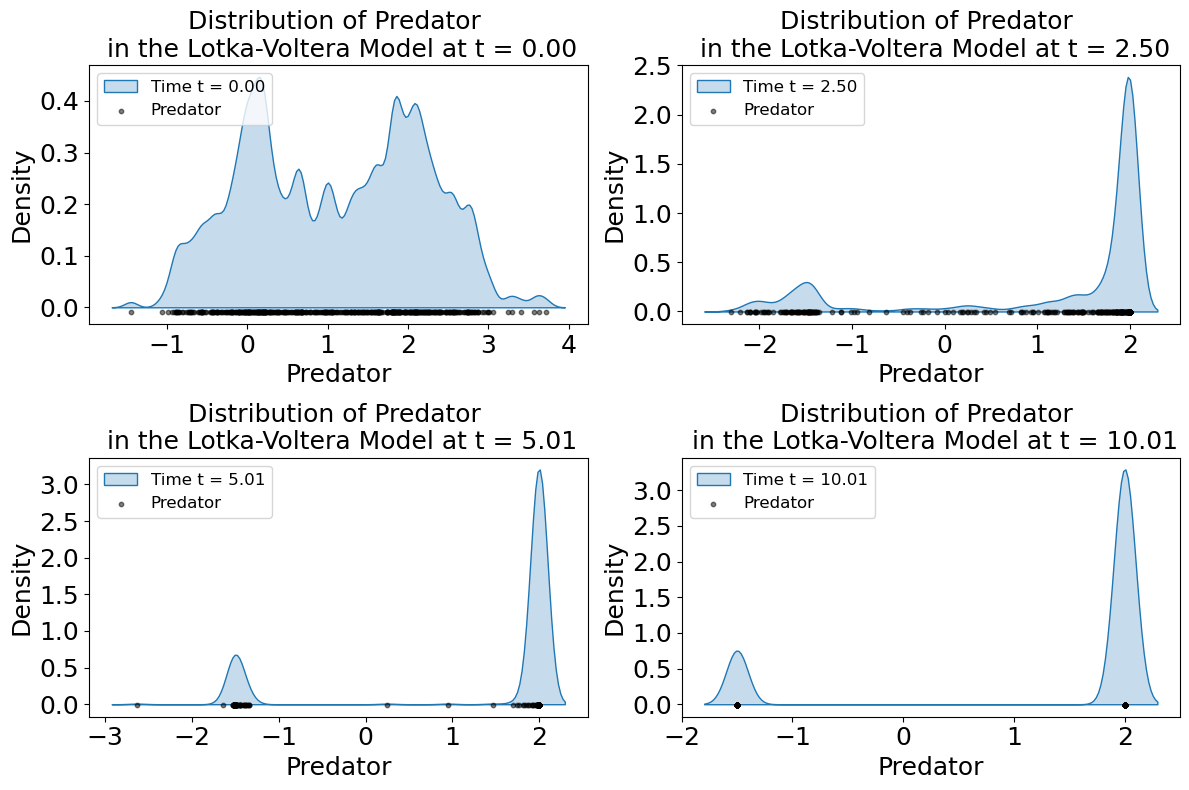

C:\Users\Chloé HIS\AppData\Local\Temp\ipykernel_22564\1396678821.py:271: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(filename, dpi=300, bbox_inches='tight')


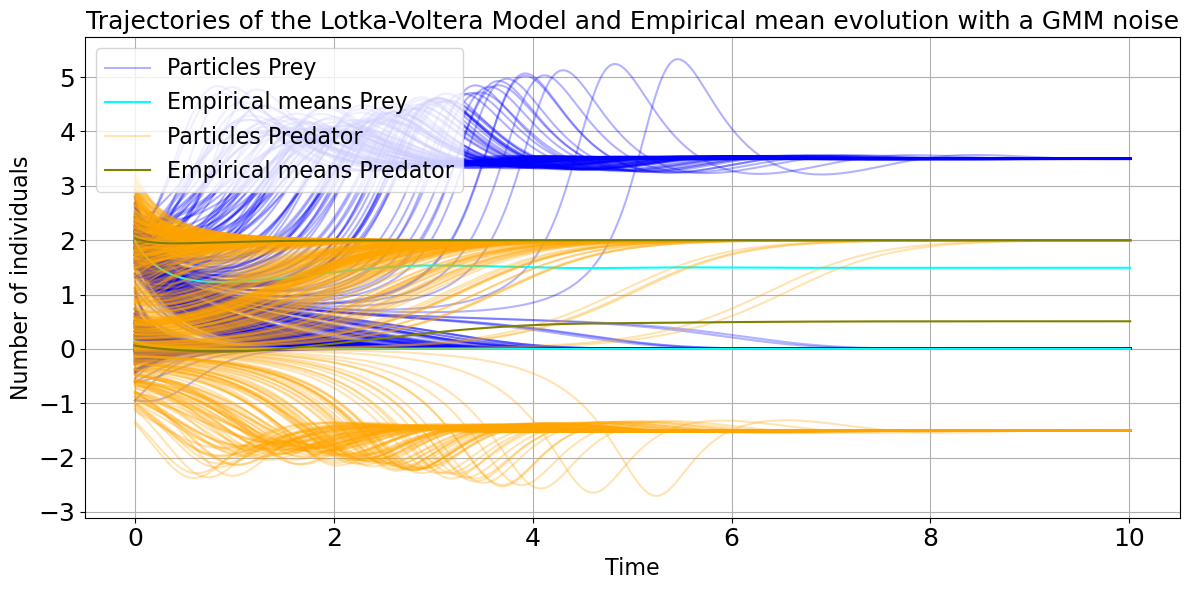

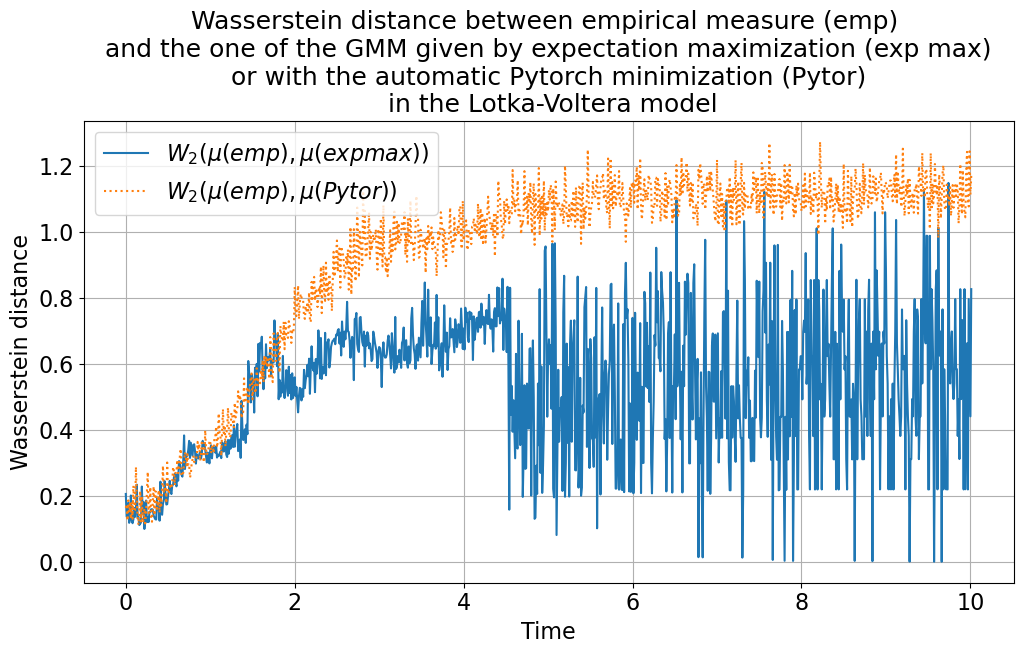

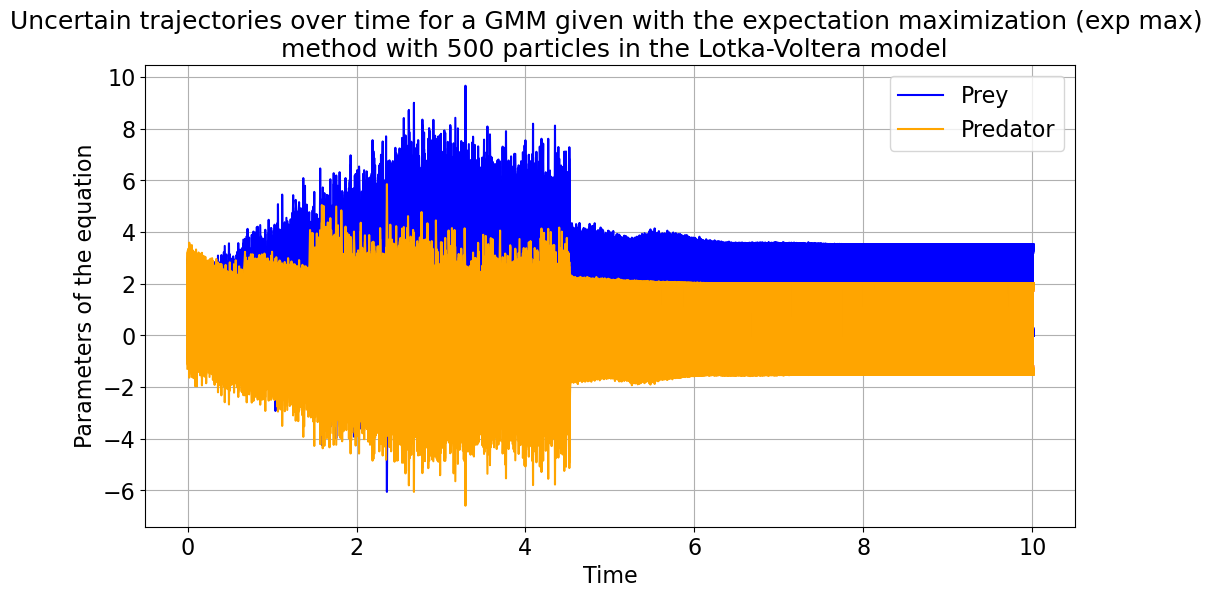

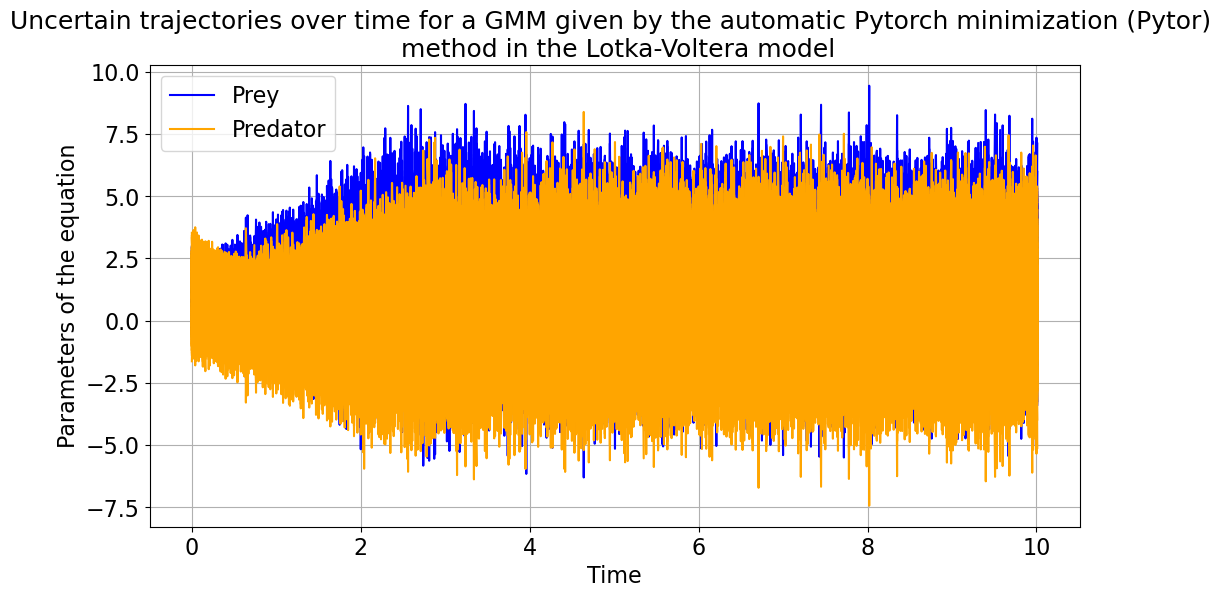

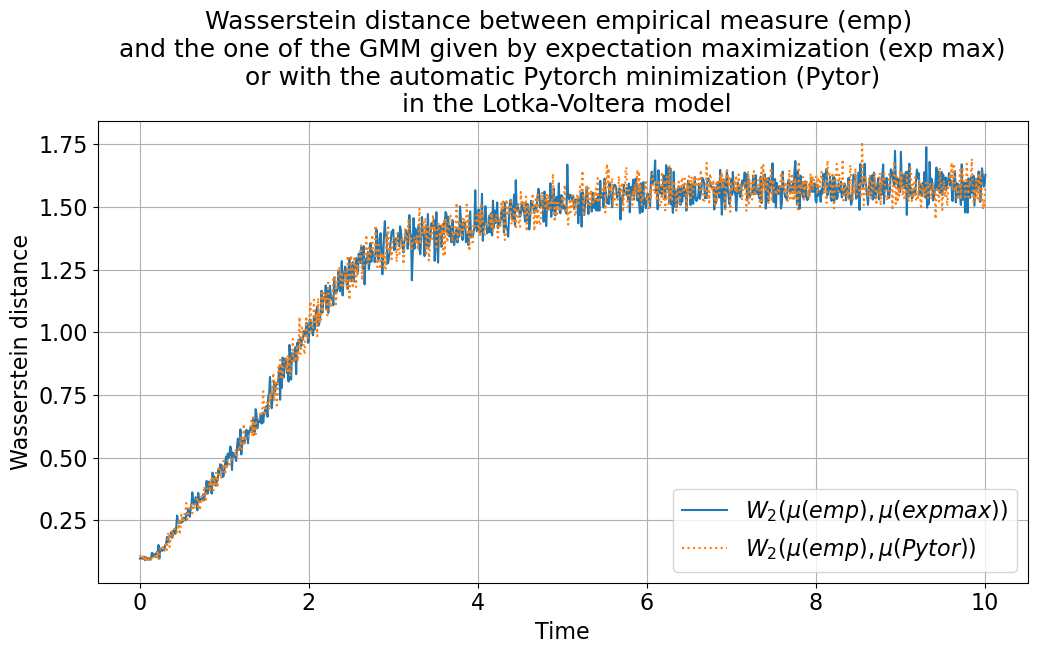

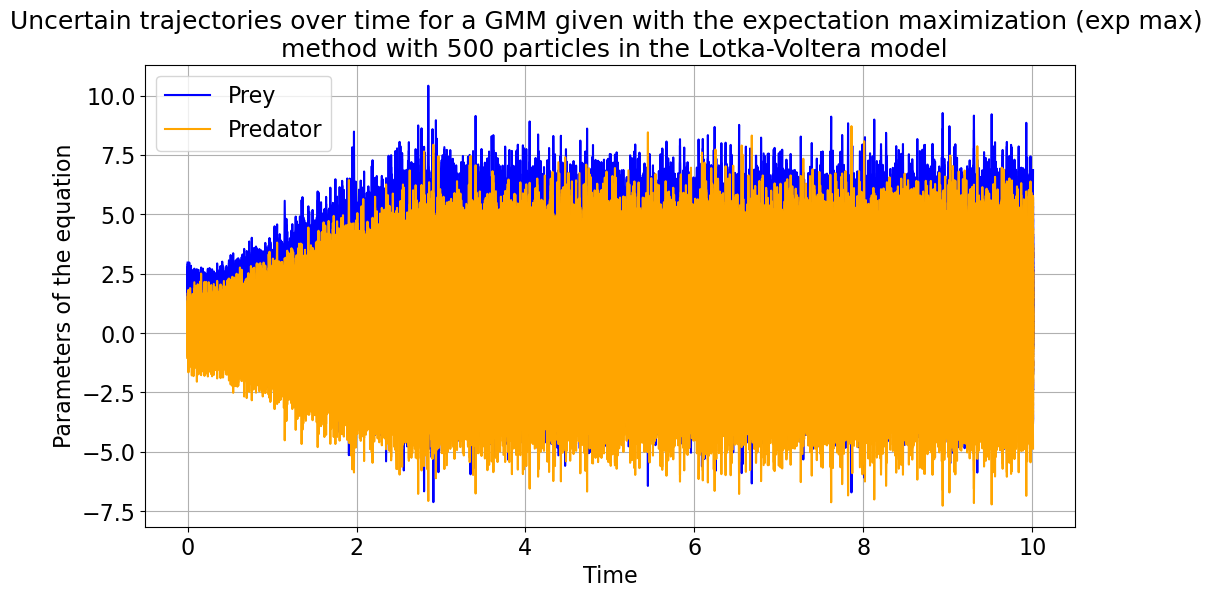

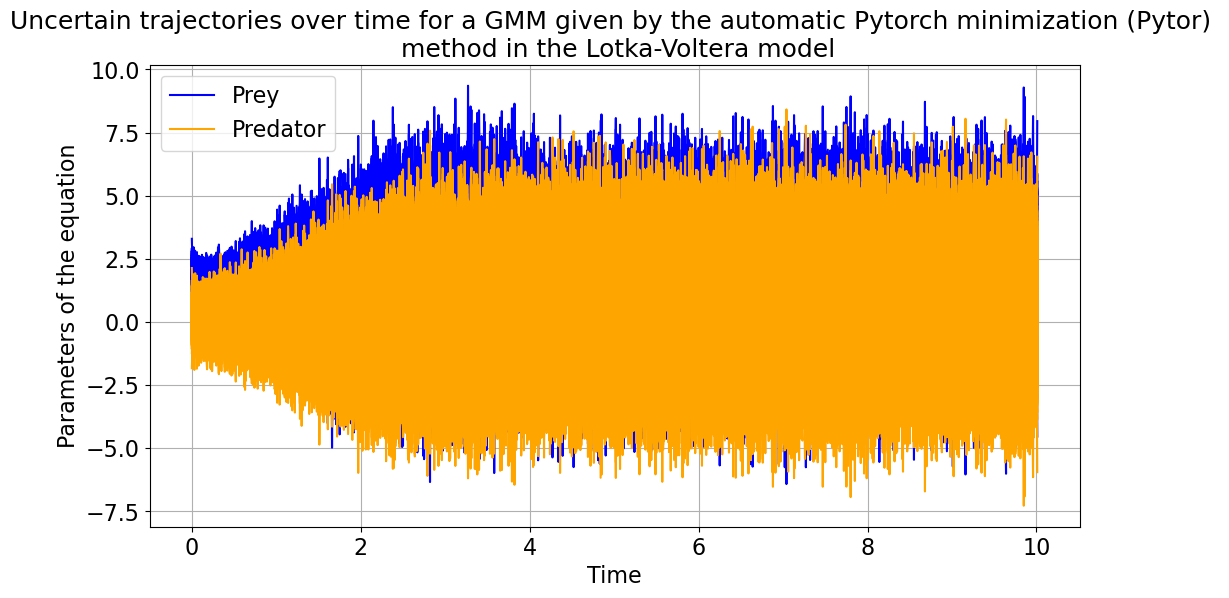

In [11]:
# Parameters

t_span=[0,10]
x0=[2,0.1]
h=1e-2
#h=5e-3
#h=1e-3
R=0.5
n_particles=500
#n_particles=1000
#n_particles= 4000
cov=np.array([
    [0.1, 0],
    [0, 0.3]])
#precision=1
precision=25e-2
X0=[[2,0.1],[0.1,2]]
COV=[np.array([
    [0.1, 0],
    [0, 0.3]]),np.array([
                [0.1, 0.05],
                [0.05, 0.3]])]
omega=[0.5,0.5]
n_components=2
n_particles_1=100
n_particles_2=1e3

X1=[x0]
COV1=[cov]
omega1=[1.0]

Model=LV(t_span,x0,h,R)

# Plots

Model.time_trajectory()

Model.uncertain_trajectory(n_particles,cov)

Model.plot_empirical_var(n_particles,cov)

Model.plot_empirical_var_GMM(n_particles,X0,COV,omega)

Model.marginals(n_particles,cov,precision)

Model.marginals_GMM(n_particles,X0,COV,omega,precision)

Model.uncertain_trajectory_GMM(n_particles,X0,COV,omega)

Model.error_approx_law_GMM(n_particles,X0,COV,omega,n_components) # GMM case

Model.error_approx_law_GMM(n_particles,X1,COV1,omega1,1) # Gaussian case

### SIR Model

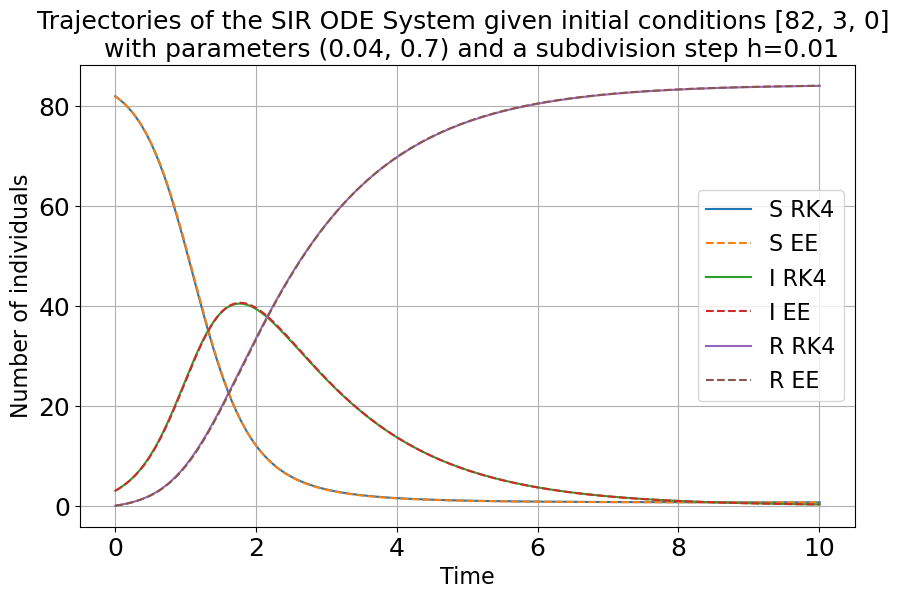

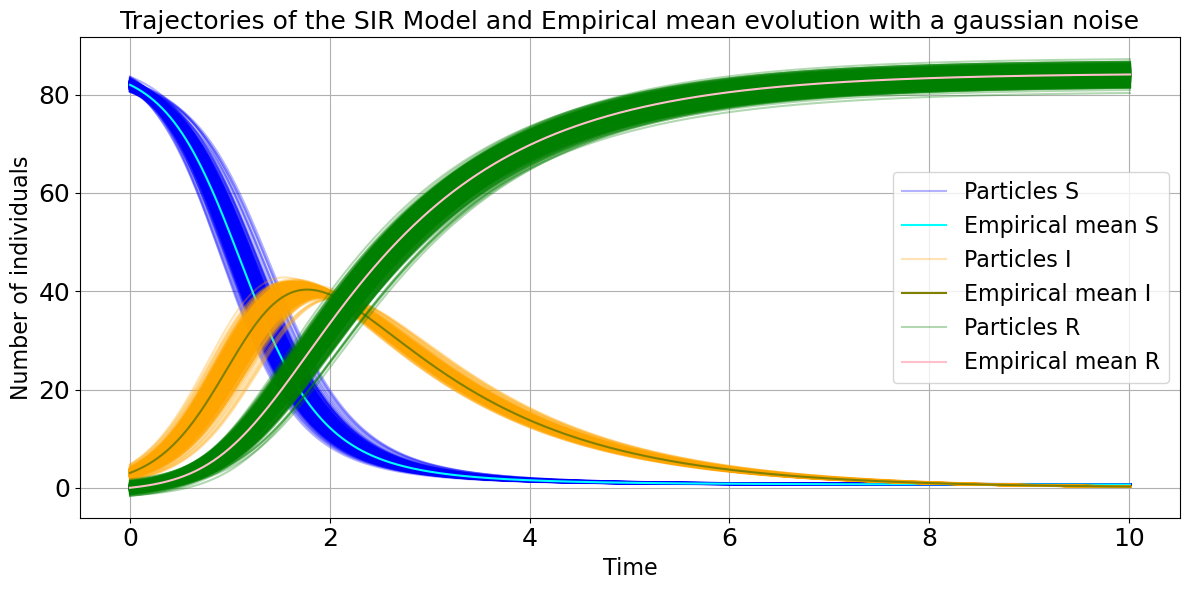

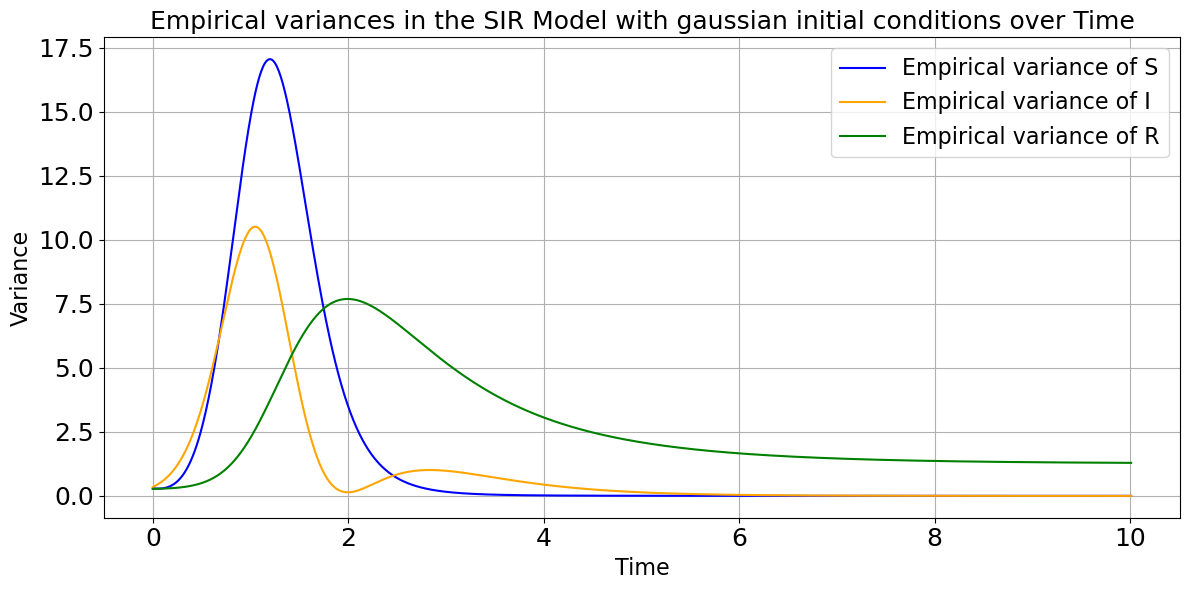

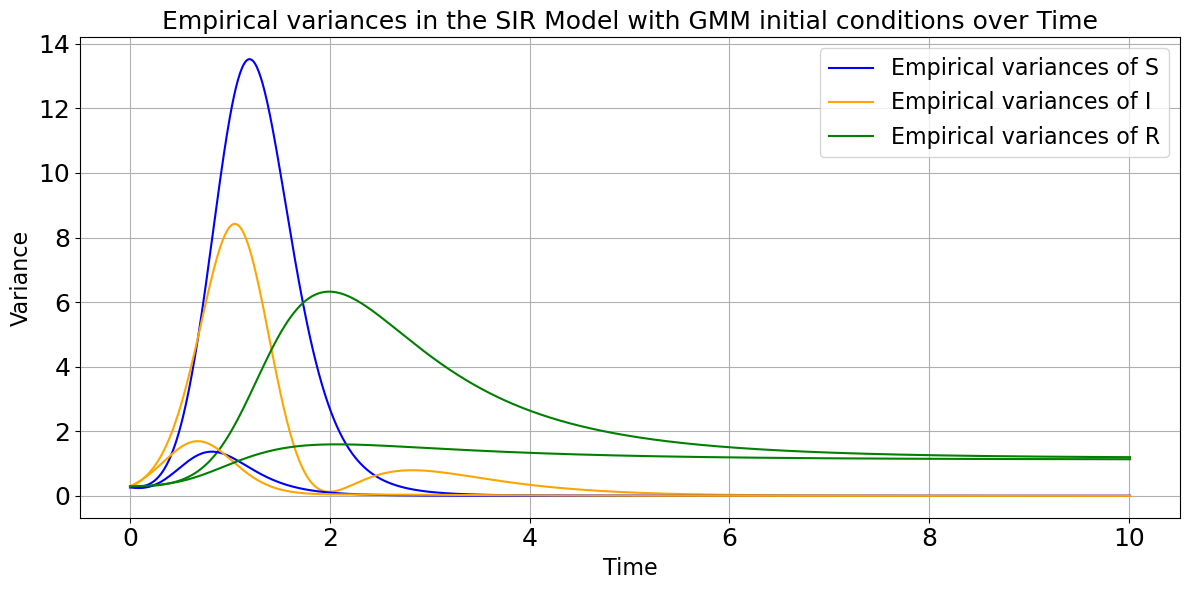

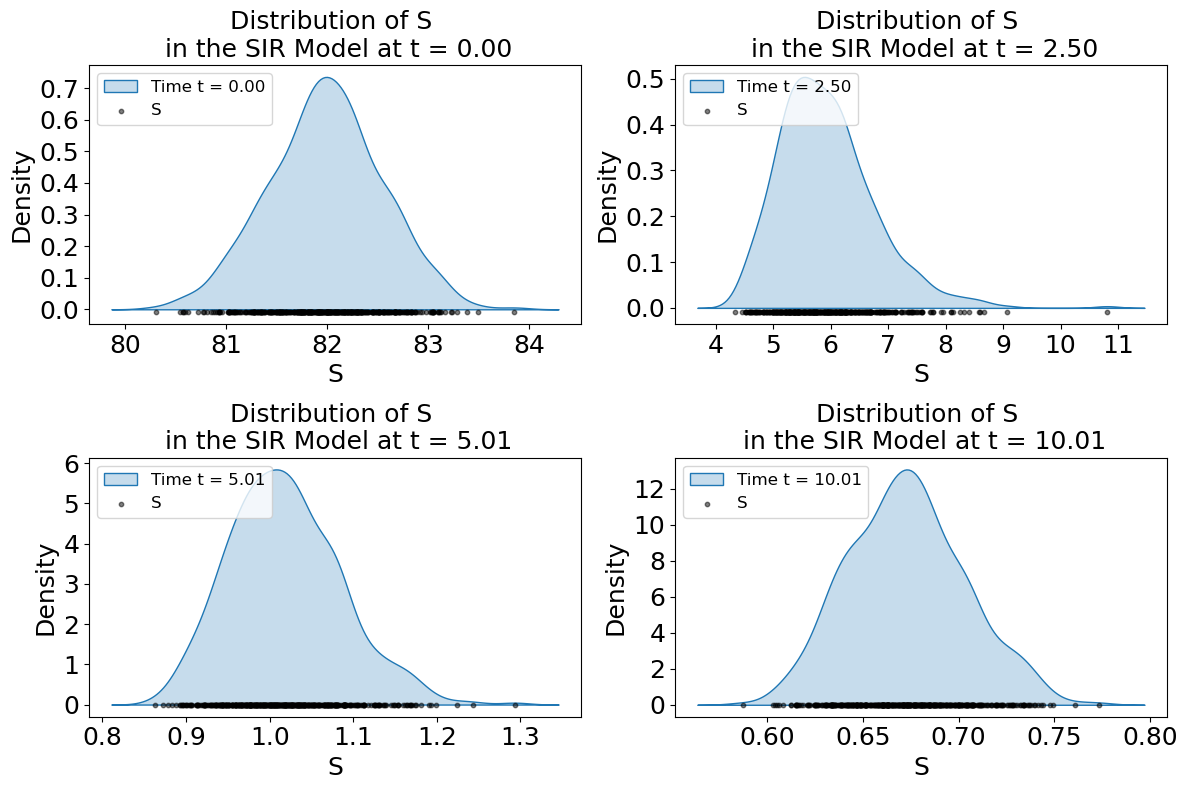

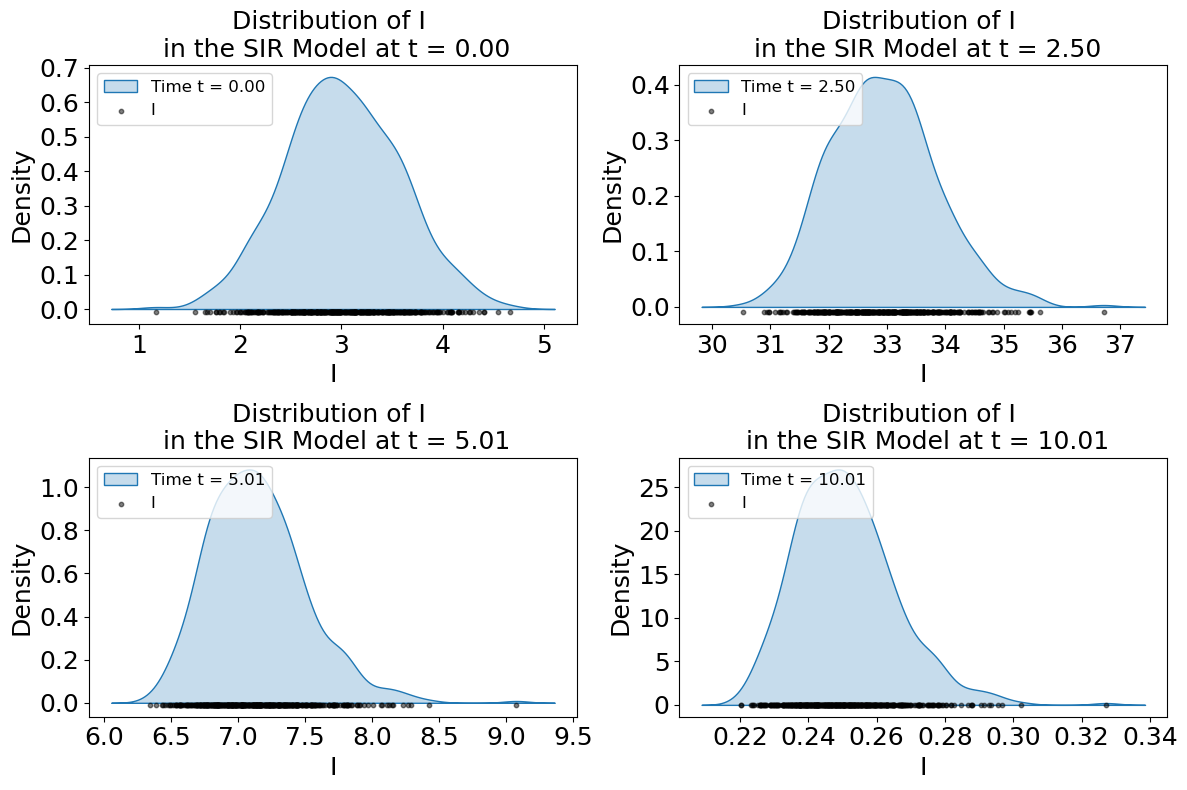

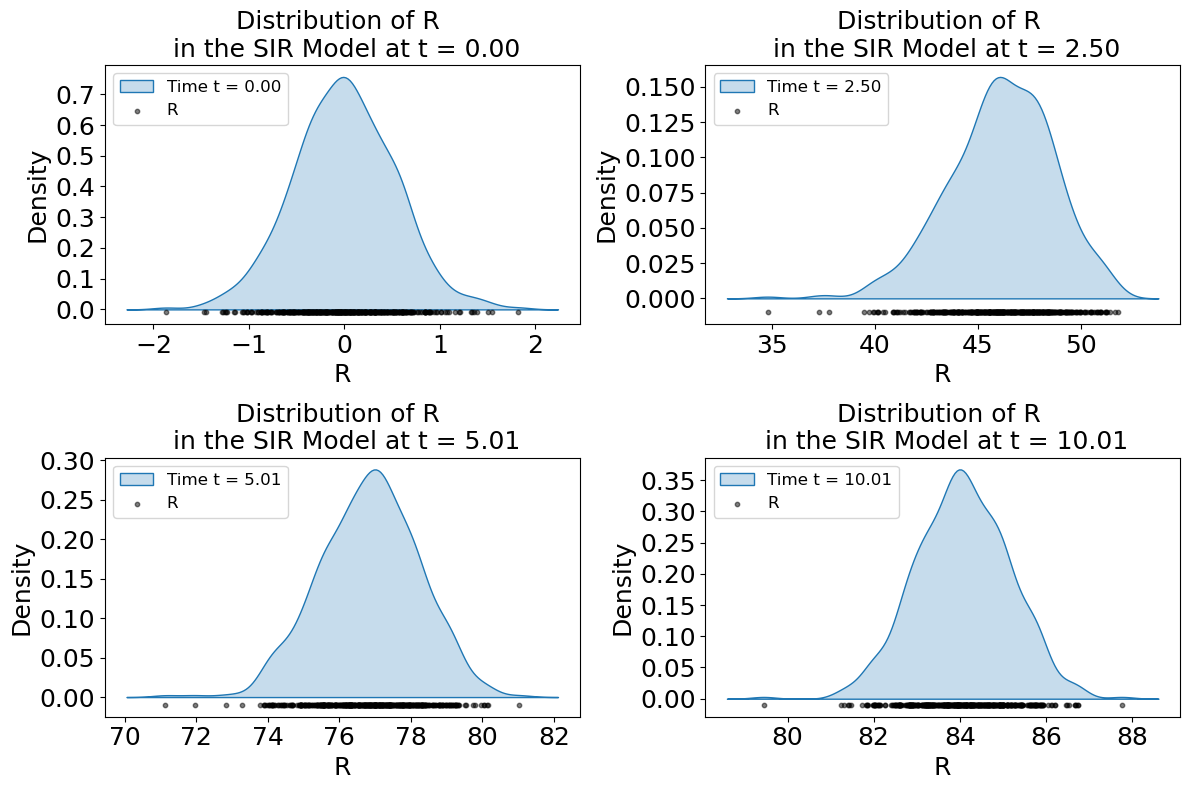

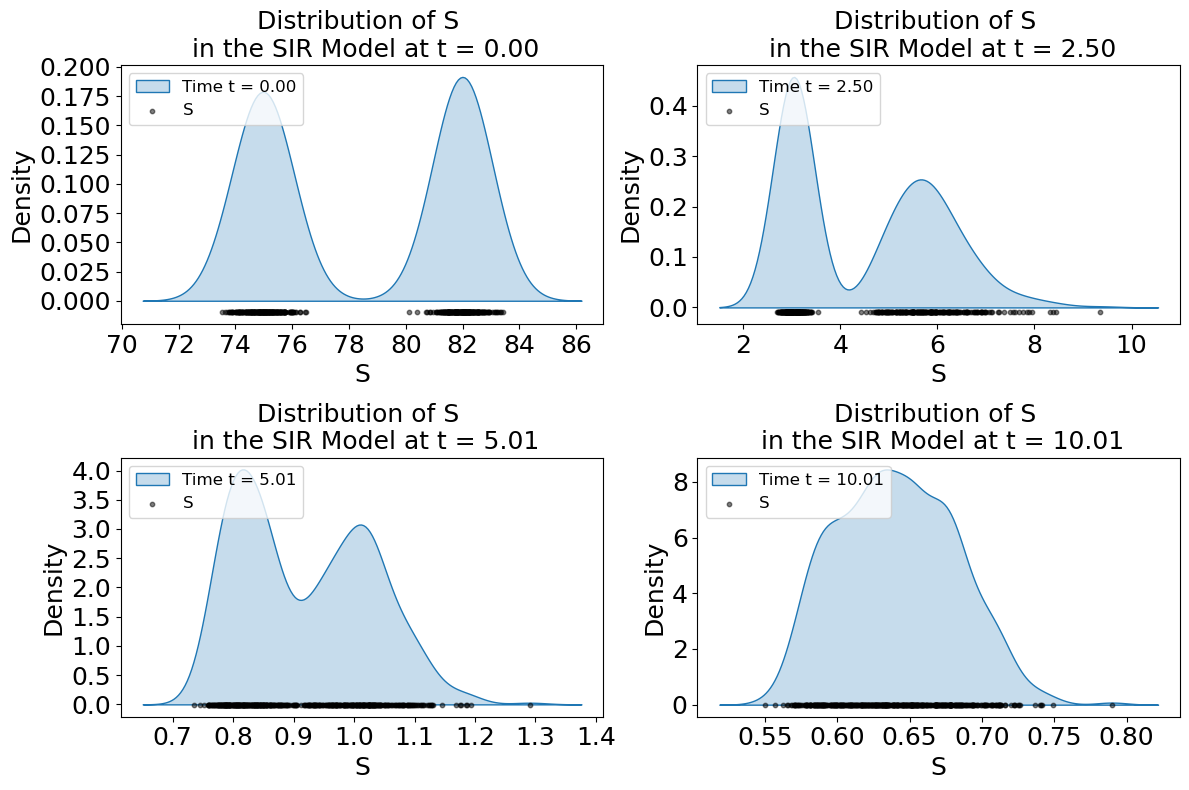

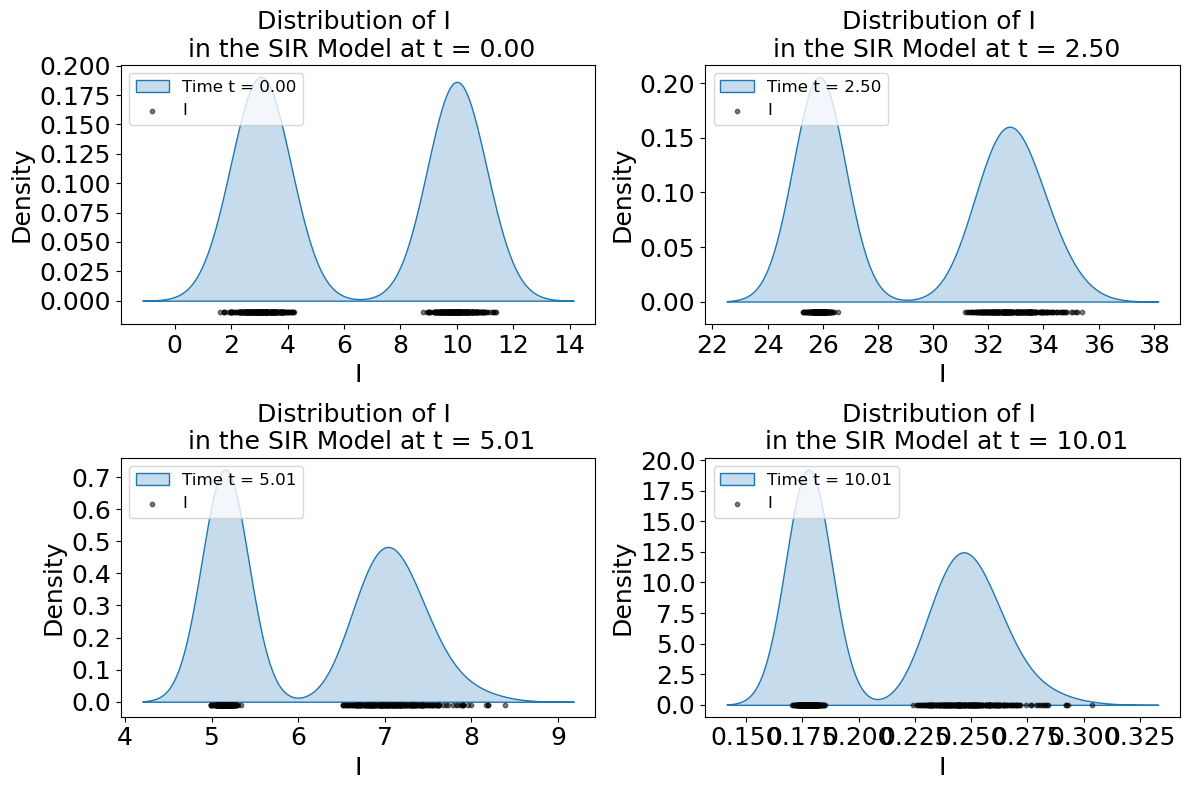

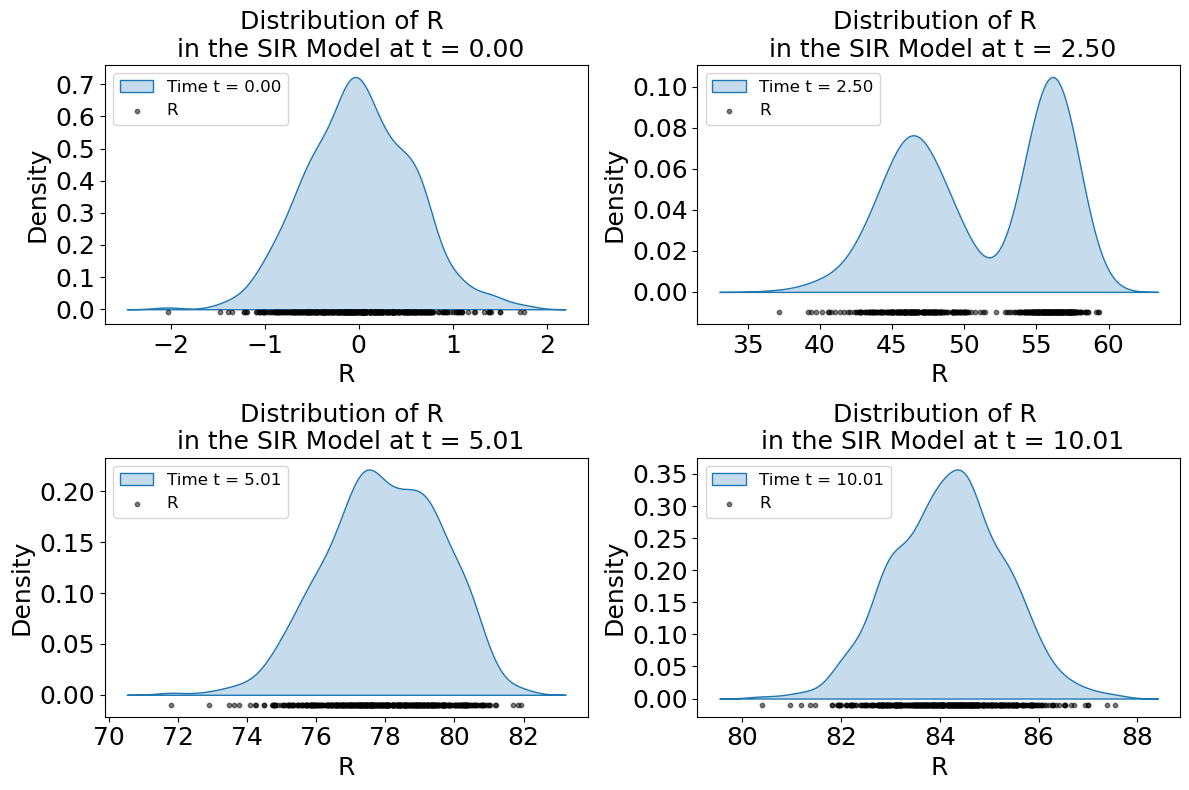

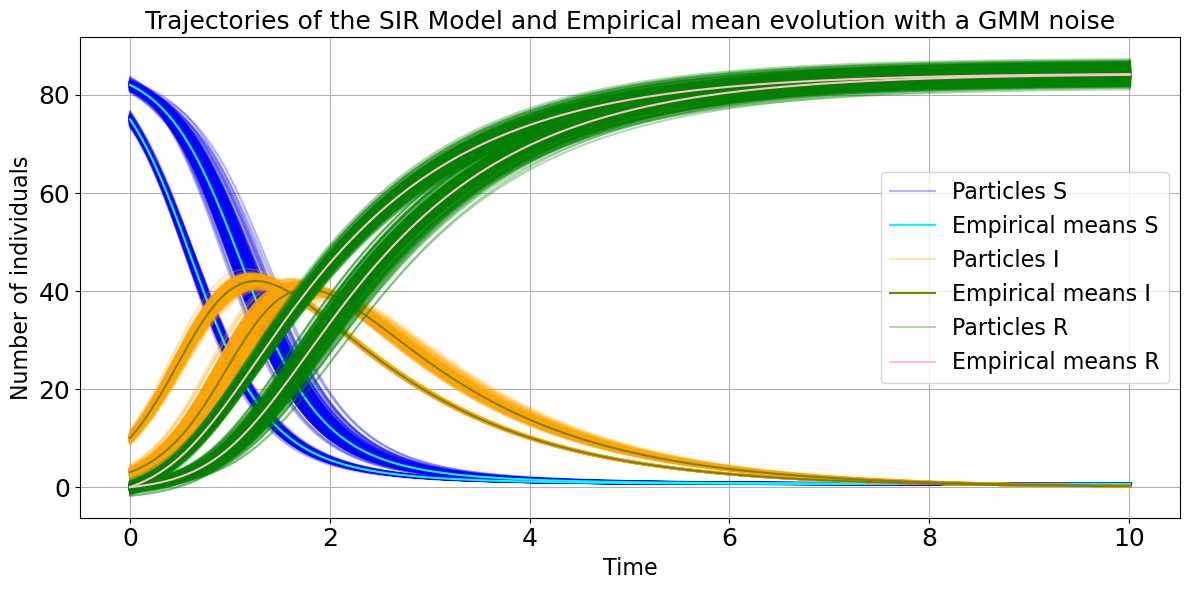

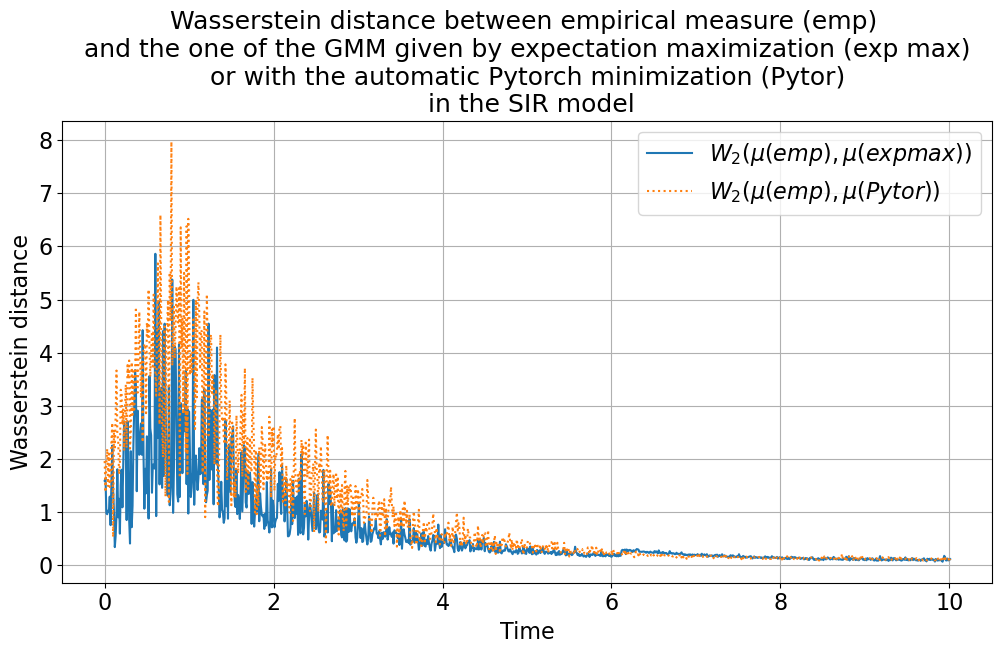

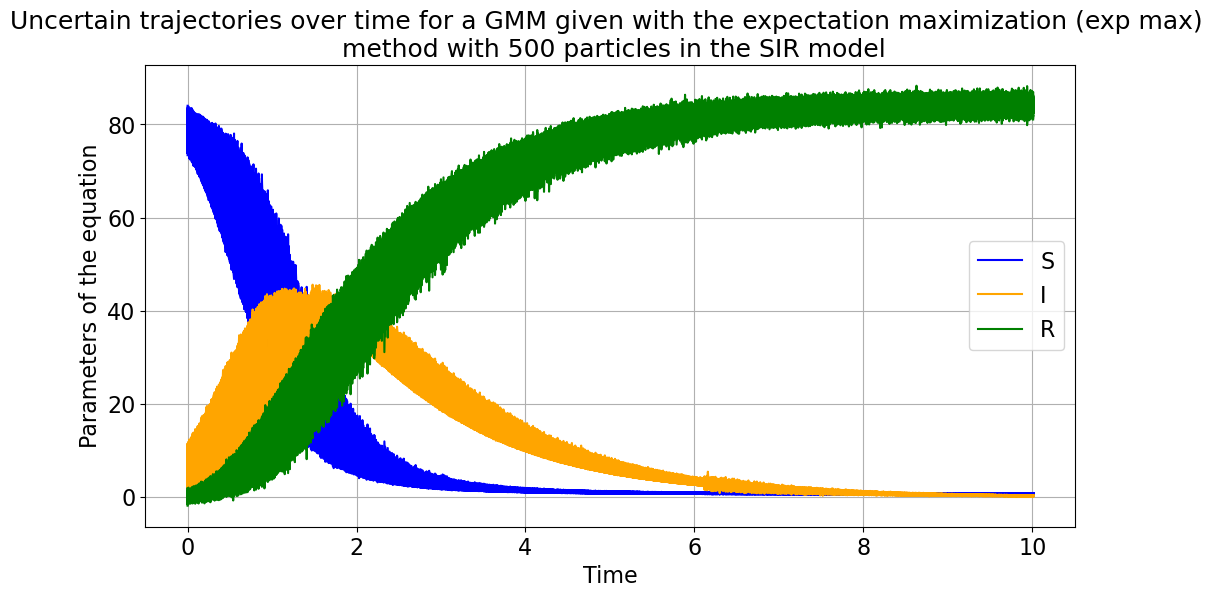

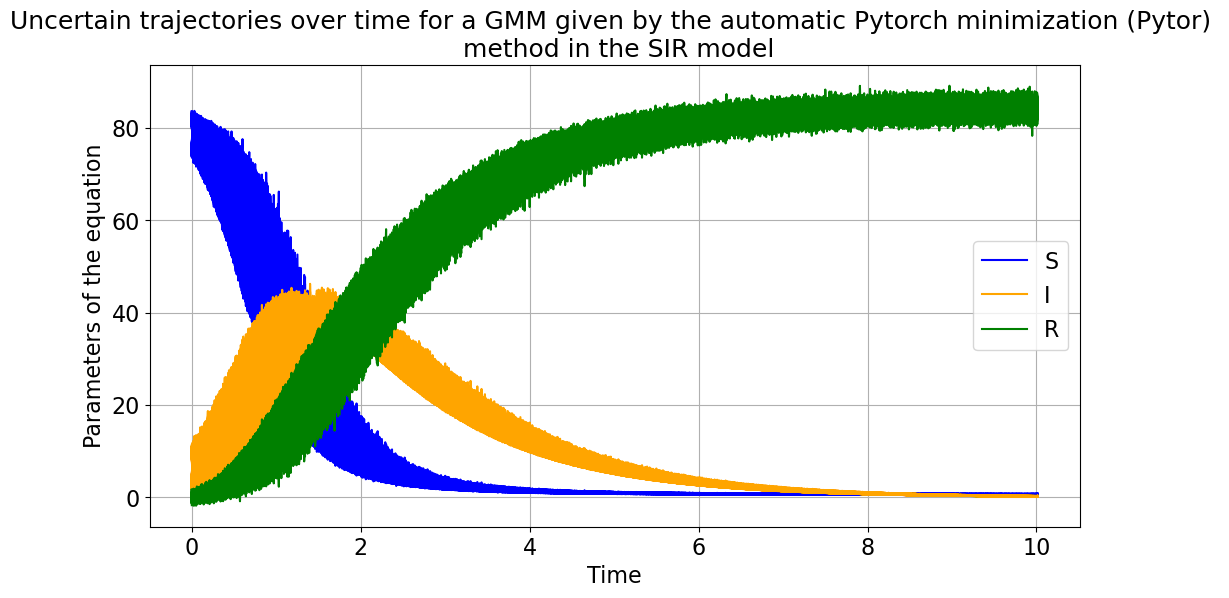

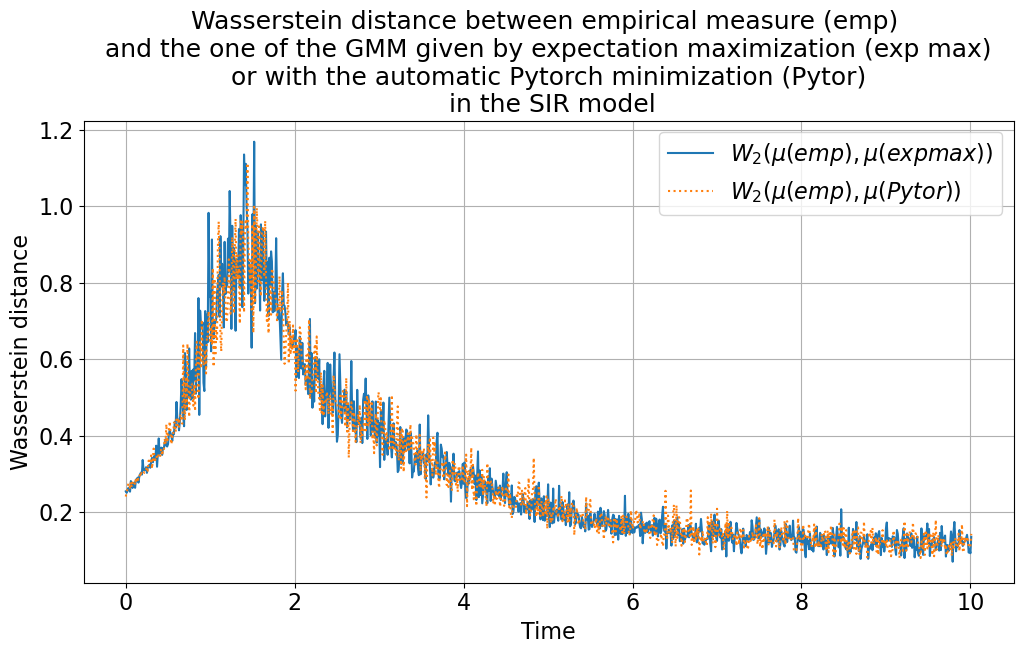

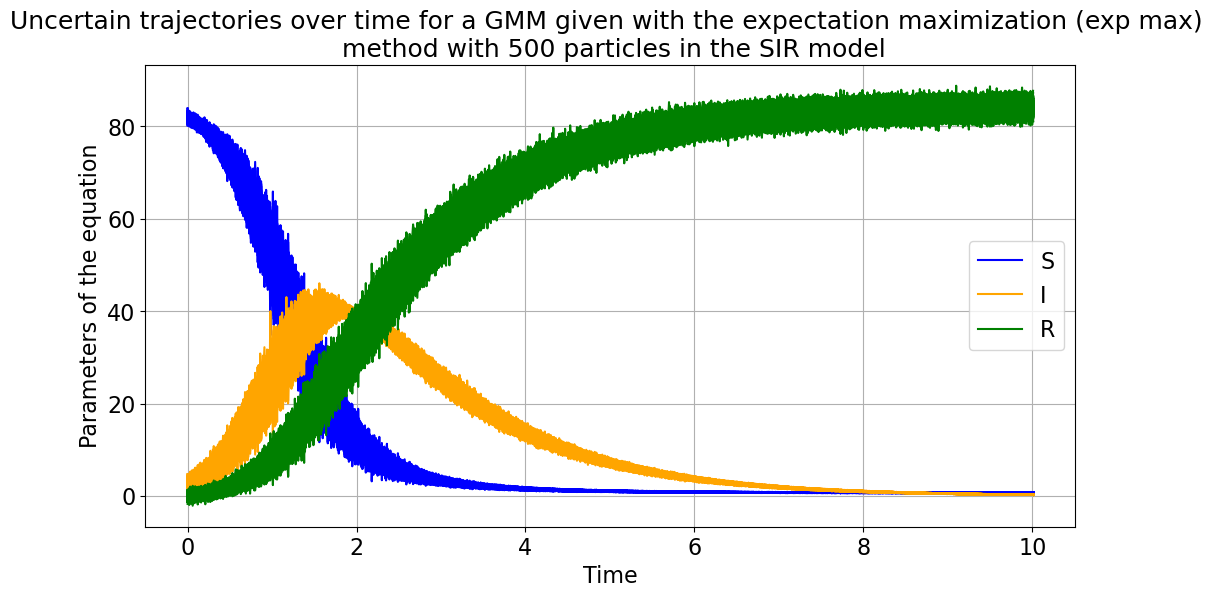

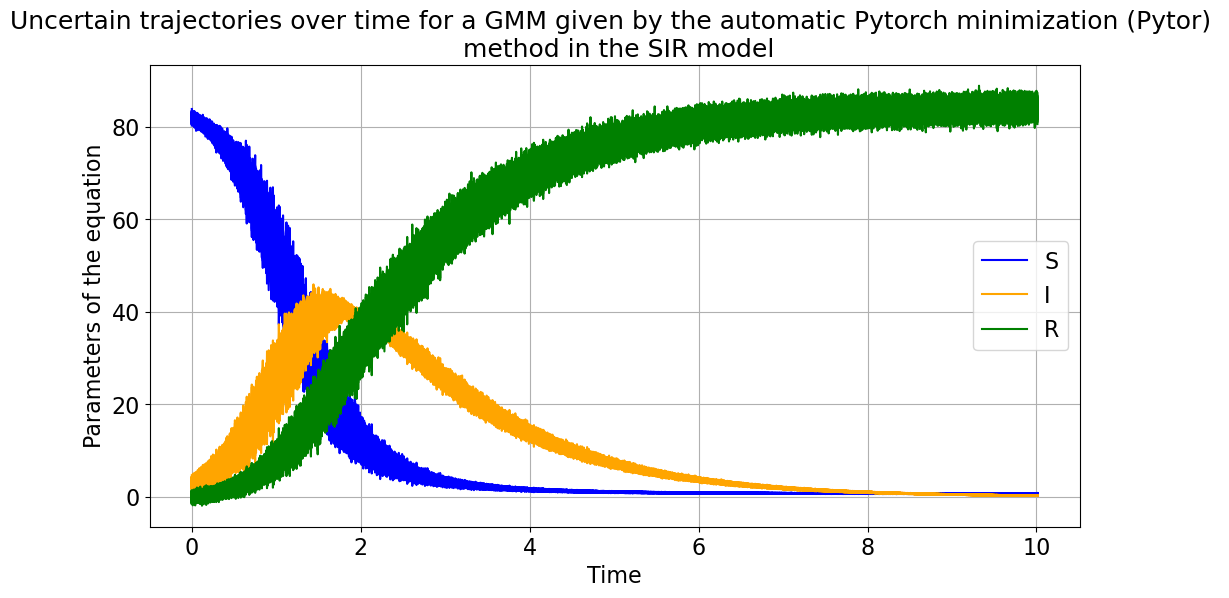

In [12]:
# Parameters

t_span=[0,10]
x0=[82,3,0]
#h=1e-1
h=1e-2
#h=1e-3
R=(0.04,0.7)
n_particles=500
#n_particles=4000
cov=np.array([
    [0.3, 0.05,0.05],
    [0.05, 0.3,0.05],
    [0.05, 0.05,0.3]])
precision=9e-1
X0=[[82,3,0],[75,10,0]]
COV=[np.array([
    [0.3, 0.05,0.05],
    [0.05, 0.3,0.05],
    [0.05, 0.05,0.3]]), np.array([
                        [0.3, 0.05,0.05],
                        [0.05, 0.3,0.05],
                        [0.05, 0.05,0.3]])]
X1=[x0]
COV1=[cov]
omega1=[1.0]

X2=[[82,3,0],[75,10,0]]
COV2=[np.array([
    [0.3, 0,0],
    [0, 0.3,0],
    [0, 0,0.3]]), np.array([
                        [0.3, 0,0],
                        [0, 0.3,0],
                        [0, 0,0.3]])]

omega=[0.5,0.5]
n_components=2 # Better with 1?
n_particles_1=100
n_particles_2=1e3

Model=SIR(t_span,x0,h,R)

# Plots

Model.time_trajectory()

Model.uncertain_trajectory(n_particles,cov)

Model.plot_empirical_var(n_particles,cov)

Model.plot_empirical_var_GMM(n_particles,X0,COV,omega)

Model.marginals(n_particles,cov,precision)

Model.marginals_GMM(n_particles,X0,COV,omega,precision)

Model.uncertain_trajectory_GMM(n_particles,X0,COV,omega)

Model.error_approx_law_GMM(n_particles,X0,COV,omega,n_components) # GMM case

Model.error_approx_law_GMM(n_particles,X1,COV1,omega1,1) # Gaussian case